## 0\. 분석 개요

1. **실험 목적**
    
    : 매출 극대화를 목표로 멤버십 구독 페이지를 개선한다.
    
2. **실험 가설**
    - 귀무 가설: A안과 B안의 ARPU에는 차이가 없다.
    - 대립 가설: A안과 B안의 ARPU에는 차이가 있다.
    
3. **성공 지표**
    - ARPU(방문자당 매출)
4. **보조 지표**
    - ARPPU(구매자당 매출)
    - 구독 전환율
    - 연간/월간 멤버십 구독 전환율
    - 'Subscribe' 버튼 클릭률
    - 월간/연간 멤버십 버튼 클릭률
5. **가드레일 지표**
    - 구독 취소율
    - 환불 문의율
6. **분석 방법**
    
    - ARPU, ARPPU: Welch t-검정
    
    - 그 외 지표: 모비율 Z검정

## 1\. 라이브러리 및 데이터 불러오기

In [1]:
# 라이브러리 불러오기
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from statsmodels.stats.proportion import proportions_ztest

In [2]:
# 데이터 불러오기
os.chdir('/content/drive/MyDrive/data_folder/sprint_mission')

user_df = pd.read_csv('유저정보데이터.csv')
daily_df = pd.read_csv('일자별행동데이터.csv')
purchase_df = pd.read_csv('결제정보데이터.csv')
subscribe_df = pd.read_csv('구독정보데이터.csv')
inquiry_df = pd.read_csv('고객센터문의데이터.csv')

## 2\. 데이터 확인

In [3]:
# 유저 정보 데이터
user_df.head()

,user_id,user_type,group,gender,age
0,U2501,신규 고객,B,여성,24
1,U2502,신규 고객,A,여성,37
2,U2503,신규 고객,B,여성,30
3,U2504,신규 고객,A,남성,51
4,U2505,신규 고객,A,여성,37


In [4]:
# 일자별 행동 데이터
daily_df.head()

,user_id,date,device,visits,button_clicks_monthly,button_clicks_yearly
0,U2501,2026-01-15,PC,1,0,1
1,U2501,2026-01-16,PC,2,0,0
2,U2501,2026-01-17,PC,3,0,1
3,U2501,2026-01-18,PC,5,1,4
4,U2501,2026-01-20,PC,4,0,2


In [5]:
# 결제 정보 데이터
purchase_df.head()

,payment_date,user_id,subscription_type,amount,payment_status
0,2026-01-15,U2501,yearly,294,성공
1,2026-01-21,U2503,yearly,294,성공
2,2026-01-20,U2504,monthly,35,성공
3,2026-01-27,U2505,monthly,35,성공
4,2026-01-22,U2506,monthly,35,성공


In [6]:
# 구독 정보 데이터
subscribe_df.head()

,user_id,subscription_type,subscribed_date,unsubscribed_date
0,U2501,yearly,2026-01-15,NaN
1,U2503,yearly,2026-01-21,NaN
2,U2504,monthly,2026-01-20,2026-01-22
3,U2505,monthly,2026-01-27,NaN
4,U2506,monthly,2026-01-22,NaN


In [7]:
# 고객 센터 문의 데이터
inquiry_df.head()

,date,user_id,inquiry_type
0,2026-01-27,U2506,결제/영수증 문의
1,2026-01-20,U2525,결제/영수증 문의
2,2026-01-12,U2552,서비스 이용 문의
3,2026-01-22,U2554,환불 문의
4,2026-01-25,U2572,서비스 이용 문의


## 3\. 데이터 전처리

### 3-1. 유저 정보 데이터 전처리

In [8]:
# 유저 정보 데이터
user_df.head()

,user_id,user_type,group,gender,age
0,U2501,신규 고객,B,여성,24
1,U2502,신규 고객,A,여성,37
2,U2503,신규 고객,B,여성,30
3,U2504,신규 고객,A,남성,51
4,U2505,신규 고객,A,여성,37


#### 3-1-1. 결측치 확인

In [9]:
# 결측치 확인
user_df.isnull().sum()

,0
user_id,0
user_type,0
group,0
gender,0
age,0


#### 3-1-2. 중복값 확인

1. 행 단위

In [10]:
# 행 단위 중복값 확인
user_df.duplicated().sum()

np.int64(0)

2. 유저 단위

In [11]:
# 유저 단위 중복값 확인
user_df['user_id'].duplicated().sum()

np.int64(0)

#### 3-1-3. 이상치 및 정의되지 않은 값 확인

In [12]:
# 유저 타입 확인
user_df['user_type'].unique()

array(['신규 고객'], dtype=object)

In [13]:
# 그룹 확인
user_df['group'].unique()

array(['B', 'A'], dtype=object)

In [14]:
# 성별 확인
user_df['gender'].unique()

array(['여성', '남성'], dtype=object)

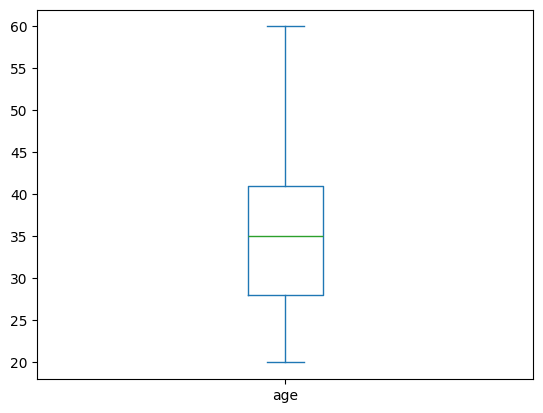

In [15]:
# 나이 분포 확인
user_df['age'].plot(kind='box')
plt.show()

#### 3-1-4. 유저 정보 데이터 전치리 결과
유저 정보 데이터의 경우 결측치 0건, 중복값 0건이었으며, 컬럼들을 모두 확인 해본 결과 컬럼별로 이상치 및 정의되지 않은 값은 따로 존재하지 않았다.

### 3-2. 일자별 행동 데이터 전처리

In [16]:
# 일자별 행동 데이터
daily_df.head()

,user_id,date,device,visits,button_clicks_monthly,button_clicks_yearly
0,U2501,2026-01-15,PC,1,0,1
1,U2501,2026-01-16,PC,2,0,0
2,U2501,2026-01-17,PC,3,0,1
3,U2501,2026-01-18,PC,5,1,4
4,U2501,2026-01-20,PC,4,0,2


#### 3-2-1. 결측치 확인

In [17]:
# 결측치 확인
daily_df.isnull().sum()

,0
user_id,0
date,0
device,0
visits,0
button_clicks_monthly,0
button_clicks_yearly,0


#### 3-2-2. 중복값 확인

In [18]:
# 중복값 확인
daily_df.duplicated().sum()

np.int64(0)

#### 3-2-3. 이상치 및 정의되지 않은 값 확인

In [19]:
# 기간 확인
print(f'{daily_df['date'].min()} - {daily_df['date'].max()}')

2026-01-15 - 2026-01-28


In [20]:
# 사용 기기 확인
daily_df['device'].unique()

array(['PC', 'Mobile'], dtype=object)

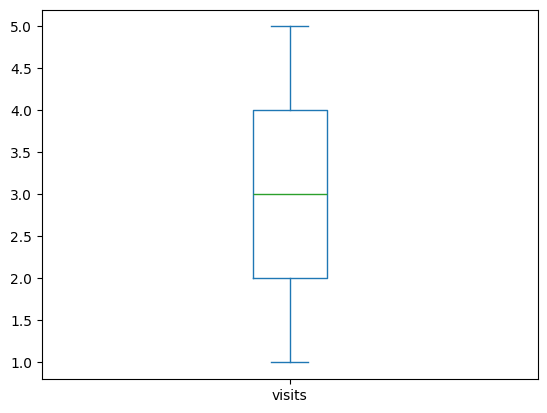

In [21]:
# 대상 페이지 방문 수 분포 확인
daily_df['visits'].plot(kind='box')
plt.show()

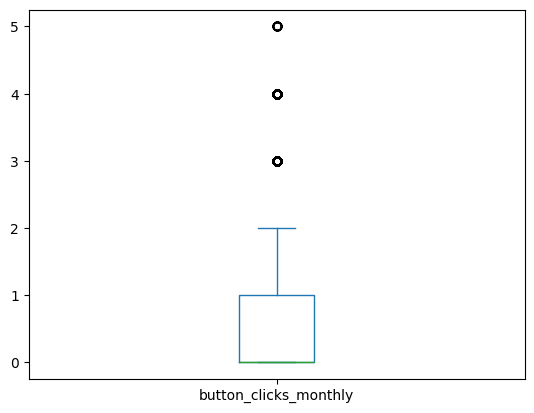

In [22]:
# 월간 버튼 클릭 수 분포 확인
daily_df['button_clicks_monthly'].plot(kind='box')
plt.show()

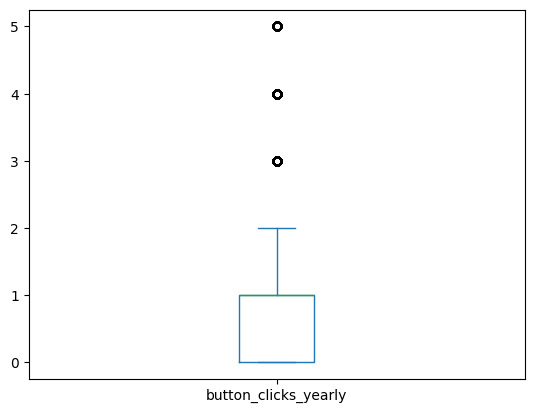

In [23]:
# 연간 버튼 클릭 수 분포 확인
daily_df['button_clicks_yearly'].plot(kind='box')
plt.show()

상자 그림 상 3, 4, 5가 이상치로 나타나고 있으나 불가능한 값은 아니므로 제거하지 않는다.

#### 3-2-4. 일자별 행동 데이터 전치리 결과
일자별 행동 데이터의 경우 결측치 0건, 중복값 0건이었으며, 컬럼들을 모두 확인 해본 결과 컬럼별로 불가능한 이상치 및 정의되지 않은 값은 따로 존재하지 않았다.

### 3-3. 결제 정보 데이터 전처리

In [24]:
# 결제 정보 데이터
purchase_df.head()

,payment_date,user_id,subscription_type,amount,payment_status
0,2026-01-15,U2501,yearly,294,성공
1,2026-01-21,U2503,yearly,294,성공
2,2026-01-20,U2504,monthly,35,성공
3,2026-01-27,U2505,monthly,35,성공
4,2026-01-22,U2506,monthly,35,성공


#### 3-3-1. 결측치 확인

In [25]:
# 결측치 확인
purchase_df.isnull().sum()

,0
payment_date,0
user_id,0
subscription_type,0
amount,0
payment_status,0


#### 3-3-2. 중복값 확인

1. 행 단위

In [26]:
# 행 단위 중복값 확인
purchase_df.duplicated().sum()

np.int64(8)

In [27]:
# 행 단위 중복값 출력
purchase_df[purchase_df.duplicated(keep=False)]

,payment_date,user_id,subscription_type,amount,payment_status
28,2026-01-17,U2590,monthly,35,실패
29,2026-01-17,U2590,monthly,35,실패
80,2026-01-19,U2745,monthly,35,실패
81,2026-01-19,U2745,monthly,35,실패
110,2026-01-17,U2831,monthly,35,실패
111,2026-01-17,U2831,monthly,35,실패
160,2026-01-27,U2961,monthly,35,실패
161,2026-01-27,U2961,monthly,35,실패
366,2026-01-21,U3473,yearly,294,실패
367,2026-01-21,U3473,yearly,294,실패


In [28]:
# 행 단위 중복값 제거
purchase_df = purchase_df.drop_duplicates()

In [29]:
# 행 단위 중복값 처리 확인
purchase_df.duplicated().sum()

np.int64(0)

2. 유저 단위

In [30]:
# 유저 단위 중복값 확인
purchase_df['user_id'].duplicated().sum()

np.int64(4)

In [31]:
# 유저 단위 중복값 출력
purchase_df[purchase_df['user_id'].duplicated(keep=False)]

,payment_date,user_id,subscription_type,amount,payment_status
28,2026-01-17,U2590,monthly,35,실패
30,2026-01-24,U2590,yearly,294,성공
255,2026-01-16,U3208,monthly,35,실패
256,2026-01-20,U3208,yearly,294,성공
366,2026-01-21,U3473,yearly,294,실패
368,2026-01-25,U3473,yearly,294,성공
384,2026-01-19,U3506,yearly,294,실패
385,2026-01-22,U3506,monthly,35,성공


중복 결제 이력이 있는 유저(U2590, U3208, U3473, U3506) 데이터를 확인한 결과, 모두 최초 결제 실패 후 재시도하여 최종 결제에 성공한 케이스이다. 핵심 지표인 ARPU 및 구독 전환율의 정확한 산출을 위해 결제 실패 건은 제외하고 최종적으로 결제에 성공한 데이터만 보존한다.

In [32]:
# 유저 단위 중복값 제거 (실패 이력 제거)
purchase_df = purchase_df[purchase_df['payment_status'] == '성공']

In [33]:
# 유저 단위 중복값 처리 확인
purchase_df['user_id'].duplicated().sum()

np.int64(0)

#### 3-3-3. 이상치 및 정의되지 않은 값 확인

In [34]:
# 기간 확인
print(f'{purchase_df['payment_date'].min()} - {purchase_df['payment_date'].max()}')

2026-01-15 - 2026-01-28


In [35]:
# 구독 타입 확인
purchase_df['subscription_type'].unique()

array(['yearly', 'monthly'], dtype=object)

In [36]:
# 결제 금액 이상치 확인
purchase_df['amount'].unique()

array([294,  35])

In [37]:
# 결제 성공 여부 확인
purchase_df['payment_status'].unique()

array(['성공'], dtype=object)

#### 3-3-4. 결제 정보 데이터 전치리 결과
결제 정보 데이터의 경우 결측치 0건, 행 단위 중복값 8건, 유저 단위 중복값 4건이었으며, 컬럼들을 모두 확인 해본 결과 컬럼별로 정의되지 않은 값은 따로 존재하지 않았다. 최종적으로는 중복값 12건을 제거하였다.

### 3-4. 구독 정보 데이터 전처리

In [38]:
# 구독 정보 데이터
subscribe_df.head()

,user_id,subscription_type,subscribed_date,unsubscribed_date
0,U2501,yearly,2026-01-15,NaN
1,U2503,yearly,2026-01-21,NaN
2,U2504,monthly,2026-01-20,2026-01-22
3,U2505,monthly,2026-01-27,NaN
4,U2506,monthly,2026-01-22,NaN


#### 3-4-1. 결측치 확인

In [39]:
# 결측치 확인
subscribe_df.isnull().sum()

,0
user_id,0
subscription_type,0
subscribed_date,0
unsubscribed_date,761


'unsubscribed_date' 컬럼은 구독 취소를 신청한 날짜로 결측치가 존재할 수 있는 컬럼이다.

#### 3-4-2. 중복값 확인

1. 행 단위

In [40]:
# 행 단위 중복값 확인
subscribe_df.duplicated().sum()

np.int64(0)

2. 유저 단위

In [41]:
# 유저 단위 중복값 확인
subscribe_df['user_id'].duplicated().sum()

np.int64(0)

#### 3-4-3. 이상치 및 정의되지 않은 값 확인

In [42]:
# 구독 타입 확인
subscribe_df['subscription_type'].unique()

array(['yearly', 'monthly'], dtype=object)

In [43]:
# 구독한 날짜의 기간 확인
print(f'{subscribe_df['subscribed_date'].min()} - {subscribe_df['subscribed_date'].max()}')

2026-01-15 - 2026-01-28


In [44]:
# 구독 취소를 신청한 날짜의 기간 확인
print(f"{subscribe_df['unsubscribed_date'].dropna().min()} - {subscribe_df['unsubscribed_date'].dropna().max()}")

2026-01-17 - 2026-01-28


#### 3-4-4. 구독 정보 데이터 전처리 결과
구독 정보 데이터의 경우 결측치 0건('unsubscribed_date' 컬럼 제외), 중복값 0건이었으며, 컬럼들을 모두 확인 해본 결과 컬럼별로 정의되지 않은 값은 따로 존재하지 않았다.

### 3-5. 고객 센터 문의 데이터 전처리

In [45]:
# 고객 센터 문의 데이터
inquiry_df.head()

,date,user_id,inquiry_type
0,2026-01-27,U2506,결제/영수증 문의
1,2026-01-20,U2525,결제/영수증 문의
2,2026-01-12,U2552,서비스 이용 문의
3,2026-01-22,U2554,환불 문의
4,2026-01-25,U2572,서비스 이용 문의


#### 3-5-1. 결측치 확인

In [46]:
# 결측치 확인
inquiry_df.isnull().sum()

,0
date,0
user_id,0
inquiry_type,0


#### 3-5-2. 중복값 확인

In [47]:
# 중복값 확인
inquiry_df.duplicated().sum()

np.int64(0)

#### 3-5-3. 이상치 및 정의되지 않은 값 확인

In [48]:
# 기간 확인
print(f'{inquiry_df['date'].min()} - {inquiry_df['date'].max()}')

2026-01-01 - 2026-02-01


In [49]:
# 정의되지 않은 기간의 데이터 수
inquiry_df[~((inquiry_df['date'] >= '2026-01-15') & (inquiry_df['date'] <= '2026-01-28'))].count()

,0
date,37
user_id,37
inquiry_type,37


In [50]:
# 실험 기간 내의 데이터만 필터링
inquiry_df = inquiry_df[(inquiry_df['date'] >= '2026-01-15') & (inquiry_df['date'] <= '2026-01-28')]

문의 데이터의 전체 기간을 확인한 결과 1월 1일부터 2월 1일까지로 실험 기간(1월 15일 ~ 1월 28일)을 벗어나는 데이터가 포함되어 있었다. 실험과 무관한 기간에 발생한 문의는 분석에 영향을 줄 수 있으므로 정확한 가드레일 지표 측정을 위해 실험 기간 내의 데이터만 필터링한다.

In [51]:
# 기간 처리 확인
print(f"{inquiry_df['date'].min()} - {inquiry_df['date'].max()}")

2026-01-15 - 2026-01-28


In [52]:
# 문의 목적 확인
inquiry_df['inquiry_type'].unique()

array(['결제/영수증 문의', '환불 문의', '서비스 이용 문의', '자동 연장 거부 문의'], dtype=object)

#### 3-5-4. 고객 센터 문의 데이터 전처리 결과
고객 센터 문의 데이터의 경우 결측치 0건, 중복값 0건이었으며, 'date' 컬럼에서 실험 기간에 벗어나는 날짜의 데이터들이 발견되었다. 최종적으로는 정의되지 않은 기간의 데이터 37건을 제거하였다.

## 4\. 데이터 병합

유저 정보 데이터, 결제 정보 데이터, 구독 정보 데이터는 모두 1유저당 1행 형태를 띄고 있는, 즉 user_id가 PK로 존재하는 데이터로 Left join을 바로 진행해도 된다.

그러나 일자별 행동 데이터와 고객 센터 문의 데이터의 경우는 1유저당 다수행의 형태를 가진다. 이 두 데이터셋을 그대로 병합할 경우 데이터가 중복으로 늘어나는 문제가 발생한다. 따라서 이 데이터셋은 병합을 위해 총 방문 횟수, 총 월간/연간 버튼 클릭 수, 문의 목적별 건수 컬럼을 만들어 1유저당 1행을 만든 뒤 병합한다.

### 4-1. 일자별 행동 데이터 요약

In [53]:
# 일자별 행동 데이터
daily_df.head()

,user_id,date,device,visits,button_clicks_monthly,button_clicks_yearly
0,U2501,2026-01-15,PC,1,0,1
1,U2501,2026-01-16,PC,2,0,0
2,U2501,2026-01-17,PC,3,0,1
3,U2501,2026-01-18,PC,5,1,4
4,U2501,2026-01-20,PC,4,0,2


In [54]:
# 유저별로 그룹화하여 총 방문 수와 클릭 수 계산
daily_group_df = daily_df.groupby('user_id').agg({
    'visits': 'sum',
    'button_clicks_monthly': 'sum',
    'button_clicks_yearly': 'sum'}).reset_index()

In [55]:
# 컬럼명 지정
daily_group_df.columns = ['user_id', 'total_visits', 'total_clicks_monthly', 'total_clicks_yearly']

In [56]:
# 요약된 일자별 행동 데이터
daily_group_df.head()

,user_id,total_visits,total_clicks_monthly,total_clicks_yearly
0,U2501,39,2,20
1,U2502,45,12,6
2,U2503,39,5,18
3,U2504,40,12,9
4,U2505,27,6,2


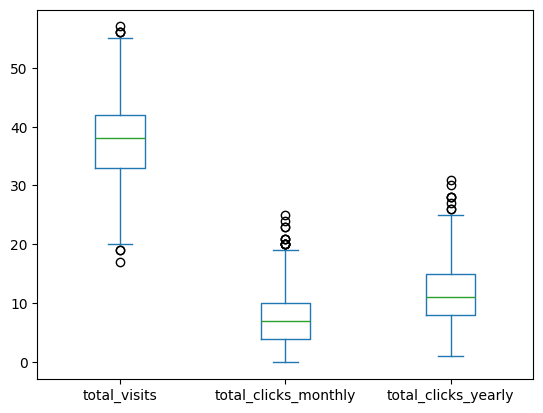

In [57]:
# 요약된 일자별 행동 데이터 분포 확인
daily_group_df.plot(kind='box')
plt.show()

눈에 띄는 불가능한 이상치는 보이지 않는다.

### 4-2. 고객 센터 문의 데이터 피벗

In [58]:
# 고객 센터 문의 데이터
inquiry_df.head()

,date,user_id,inquiry_type
0,2026-01-27,U2506,결제/영수증 문의
1,2026-01-20,U2525,결제/영수증 문의
3,2026-01-22,U2554,환불 문의
4,2026-01-25,U2572,서비스 이용 문의
5,2026-01-24,U2590,환불 문의


In [59]:
# 유저 아이디와 문의 목적으로 빈도수 테이블 생성
inquiry_group_df = pd.crosstab(inquiry_df['user_id'], inquiry_df['inquiry_type']).reset_index()

In [60]:
# 컬럼명 명어로 통일
inquiry_dict = {
    '결제/영수증 문의': 'payment_receipt_inquiry',
    '서비스 이용 문의': 'service_inquiry',
    '자동 연장 거부 문의': 'pay_cancel_inquiry',
    '환불 문의': 'refund_inquiry'}

inquiry_group_df = inquiry_group_df.rename(columns=inquiry_dict)

In [61]:
# 피벗된 고객 센터 문의 데이터
inquiry_group_df.head()

inquiry_type,user_id,payment_receipt_inquiry,service_inquiry,pay_cancel_inquiry,refund_inquiry
0,U2506,1,0,0,0
1,U2525,1,0,0,0
2,U2554,0,0,0,1
3,U2572,0,1,0,0
4,U2590,0,0,0,1


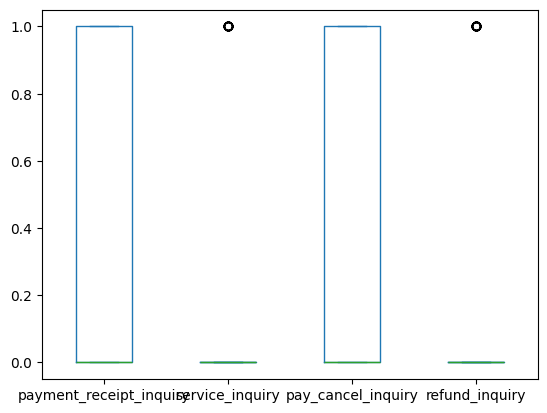

In [62]:
# 피벗된 고객 센터 문의 데이터 분포 확인
inquiry_group_df.plot(kind='box')
plt.show()

데이터 모두 0건 또는 1건으로 이상치는 보이지 않는다.

### 4-3. 데이터 전체 병합

In [63]:
# 유저 정보 데이터와 결제 정보 데이터 병합
df = user_df.merge(purchase_df, on='user_id', how='left')

In [64]:
# 구독 정보 데이터 병합
df = df.merge(subscribe_df, on='user_id', how='left')

In [65]:
# 요약된 일자별 행동 데이터 병합
df = df.merge(daily_group_df, on='user_id', how='left')

In [66]:
# 피벗된 고객 센터 문의 데이터 병합
df = df.merge(inquiry_group_df, on='user_id', how='left')

In [67]:
# 병합된 데이터
df.head()

,user_id,user_type,group,gender,age,payment_date,subscription_type_x,amount,payment_status,subscription_type_y,subscribed_date,unsubscribed_date,total_visits,total_clicks_monthly,total_clicks_yearly,payment_receipt_inquiry,service_inquiry,pay_cancel_inquiry,refund_inquiry
0,U2501,신규 고객,B,여성,24,2026-01-15,yearly,294.0,성공,yearly,2026-01-15,NaN,39,2,20,NaN,NaN,NaN,NaN
1,U2502,신규 고객,A,여성,37,NaN,NaN,NaN,NaN,NaN,NaN,NaN,45,12,6,NaN,NaN,NaN,NaN
2,U2503,신규 고객,B,여성,30,2026-01-21,yearly,294.0,성공,yearly,2026-01-21,NaN,39,5,18,NaN,NaN,NaN,NaN
3,U2504,신규 고객,A,남성,51,2026-01-20,monthly,35.0,성공,monthly,2026-01-20,2026-01-22,40,12,9,NaN,NaN,NaN,NaN
4,U2505,신규 고객,A,여성,37,2026-01-27,monthly,35.0,성공,monthly,2026-01-27,NaN,27,6,2,NaN,NaN,NaN,NaN


## 5\. 병합된 데이터 전처리

### 5-1. 병합된 데이터 파악

In [68]:
# 병합된 데이터
df.head()

,user_id,user_type,group,gender,age,payment_date,subscription_type_x,amount,payment_status,subscription_type_y,subscribed_date,unsubscribed_date,total_visits,total_clicks_monthly,total_clicks_yearly,payment_receipt_inquiry,service_inquiry,pay_cancel_inquiry,refund_inquiry
0,U2501,신규 고객,B,여성,24,2026-01-15,yearly,294.0,성공,yearly,2026-01-15,NaN,39,2,20,NaN,NaN,NaN,NaN
1,U2502,신규 고객,A,여성,37,NaN,NaN,NaN,NaN,NaN,NaN,NaN,45,12,6,NaN,NaN,NaN,NaN
2,U2503,신규 고객,B,여성,30,2026-01-21,yearly,294.0,성공,yearly,2026-01-21,NaN,39,5,18,NaN,NaN,NaN,NaN
3,U2504,신규 고객,A,남성,51,2026-01-20,monthly,35.0,성공,monthly,2026-01-20,2026-01-22,40,12,9,NaN,NaN,NaN,NaN
4,U2505,신규 고객,A,여성,37,2026-01-27,monthly,35.0,성공,monthly,2026-01-27,NaN,27,6,2,NaN,NaN,NaN,NaN


In [69]:
# 통계량 확인
df.describe(include='all')

,user_id,user_type,group,gender,age,payment_date,subscription_type_x,amount,payment_status,subscription_type_y,subscribed_date,unsubscribed_date,total_visits,total_clicks_monthly,total_clicks_yearly,payment_receipt_inquiry,service_inquiry,pay_cancel_inquiry,refund_inquiry
count,2500,2500,2500,2500,2500.000000,913,913,913.000000,913,913,913,152,2500.000000,2500.000000,2500.000000,142.000000,142.000000,142.000000,142.000000
unique,2500,1,2,2,NaN,14,2,NaN,1,2,14,12,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,U5000,신규 고객,A,남성,NaN,2026-01-15,yearly,NaN,성공,yearly,2026-01-15,2026-01-28,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,1,2500,1277,1271,NaN,81,576,NaN,913,576,81,27,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,NaN,34.723600,NaN,NaN,198.399781,NaN,NaN,NaN,NaN,37.667600,7.611600,11.309200,0.309859,0.176056,0.309859,0.204225
std,NaN,NaN,NaN,NaN,9.076792,NaN,NaN,125.052722,NaN,NaN,NaN,NaN,6.078214,4.100765,4.793285,0.464072,0.382216,0.464072,0.404561
min,NaN,NaN,NaN,NaN,20.000000,NaN,NaN,35.000000,NaN,NaN,NaN,NaN,17.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,NaN,NaN,NaN,NaN,28.000000,NaN,NaN,35.000000,NaN,NaN,NaN,NaN,33.000000,4.000000,8.000000,0.000000,0.000000,0.000000,0.000000
50%,NaN,NaN,NaN,NaN,35.000000,NaN,NaN,294.000000,NaN,NaN,NaN,NaN,38.000000,7.000000,11.000000,0.000000,0.000000,0.000000,0.000000
75%,NaN,NaN,NaN,NaN,41.000000,NaN,NaN,294.000000,NaN,NaN,NaN,NaN,42.000000,10.000000,15.000000,1.000000,0.000000,1.000000,0.000000


In [70]:
# 데이터 구조 확인
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 19 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   user_id                  2500 non-null   object 
 1   user_type                2500 non-null   object 
 2   group                    2500 non-null   object 
 3   gender                   2500 non-null   object 
 4   age                      2500 non-null   int64  
 5   payment_date             913 non-null    object 
 6   subscription_type_x      913 non-null    object 
 7   amount                   913 non-null    float64
 8   payment_status           913 non-null    object 
 9   subscription_type_y      913 non-null    object 
 10  subscribed_date          913 non-null    object 
 11  unsubscribed_date        152 non-null    object 
 12  total_visits             2500 non-null   int64  
 13  total_clicks_monthly     2500 non-null   int64  
 14  total_clicks_yearly     

### 5-2. 중복 컬럼 처리(subscription_type)

In [71]:
# 두 컬럼의 값이 동일한지 확인
df['subscription_type_x'].equals(df['subscription_type_y'])

True

In [72]:
# 하나의 컬럼만 남기고 컬럼명 변경
df = df.rename(columns={'subscription_type_x': 'subscription_type'})

In [73]:
# 중복 컬럼 삭제
df = df.drop(columns=['subscription_type_y'])

In [74]:
# 컬럼 목록 확인
df.columns

Index(['user_id', 'user_type', 'group', 'gender', 'age', 'payment_date',
       'subscription_type', 'amount', 'payment_status', 'subscribed_date',
       'unsubscribed_date', 'total_visits', 'total_clicks_monthly',
       'total_clicks_yearly', 'payment_receipt_inquiry', 'service_inquiry',
       'pay_cancel_inquiry', 'refund_inquiry'],
      dtype='object')

### 5-3. 날짜 컬럼 데이터 타입 변경

In [75]:
# 날짜 컬럼
date_cols = ['payment_date', 'subscribed_date', 'unsubscribed_date']

In [76]:
# 데이터 타입 변환
for col in date_cols:
    if col in df.columns:
       df[col] = pd.to_datetime(df[col])

In [77]:
# 데이터 타입 확인
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   user_id                  2500 non-null   object        
 1   user_type                2500 non-null   object        
 2   group                    2500 non-null   object        
 3   gender                   2500 non-null   object        
 4   age                      2500 non-null   int64         
 5   payment_date             913 non-null    datetime64[ns]
 6   subscription_type        913 non-null    object        
 7   amount                   913 non-null    float64       
 8   payment_status           913 non-null    object        
 9   subscribed_date          913 non-null    datetime64[ns]
 10  unsubscribed_date        152 non-null    datetime64[ns]
 11  total_visits             2500 non-null   int64         
 12  total_clicks_monthly     2500 non-

### 5-4. 결측치 확인

In [78]:
# 결측치 확인
df.isnull().sum()

,0
user_id,0
user_type,0
group,0
gender,0
age,0
payment_date,1587
subscription_type,1587
amount,1587
payment_status,1587
subscribed_date,1587


데이터 병합 결과, user_df를 기준으로 데이터를 붙이는 과정에서 행동 데이터나 문의 데이터에 기록이 없는 유저들의 데이터가 결측치로 생성된 것을 확인할 수 있다.

이러한 결측치는 다음과 같이 처리한다.

1. **수치형 컬럼 (결제 금액,  문의 건수)**
   * amount 및 각종 고객 센터 문의 건수 컬럼의 결측치는 테스트 기간 동안 해당 행동이 전혀 발생하지 않았음을 의미한다.
   * 따라서 평균이나 합계 같은 통계 연산이 정상적으로 가능하도록 이 컬럼들의 결측치는 모두 숫자 0으로 대체한다.

2. **날짜 및 상태 컬럼 (결제일, 구독일, 구독 취소 신청일, 구독 타입, 결제 성공 여부)**
   * payment_date, subscribed_date, unsubscribed_date, `payment_status 등의 컬럼에 있는 결측치는 해당 이벤트 자체가 발생하지 않았음, 구독 유지 유저이므로 해지일이 없음 등을 뜻하는 정상적인 상태이다.
   * 날짜나 문자형 컬럼을 숫자 0이나 임의의 가짜 날짜로 채워버리면 오히려 데이터 왜곡이나 연산 오류를 유발할 수 있다. 따라서 이 컬럼들의 결측치는 NaN 상태를 그대로 유지하여 이벤트 미발생 사실을 보존한다.

In [79]:
# 결측치가 존재하는 수치형 컬럼 목록
is_null_cols = [
    'amount',
    'payment_receipt_inquiry',
    'service_inquiry',
    'pay_cancel_inquiry',
    'refund_inquiry']

In [80]:
# 해당 컬럼들의 NaN을 0으로 채우기
df[is_null_cols] = df[is_null_cols].fillna(0)

In [81]:
# 결측치 처리 확인
df.isnull().sum()

,0
user_id,0
user_type,0
group,0
gender,0
age,0
payment_date,1587
subscription_type,1587
amount,0
payment_status,1587
subscribed_date,1587


### 5-5. 중복값 확인

In [82]:
# 중복값 확인
df.duplicated().sum()

np.int64(0)

## 6\. EDA

In [86]:
# 데이터 크기 확인
df.shape

(2500, 18)

In [87]:
# A/B 그룹별 유저 수 확인
df['group'].value_counts()

,count
group,
A,1277
B,1223


A그룹의 1,277명, B그룹이 1,223명으로 표본의 수가 충분히 크므로 중심극한정리에 의해 표본 평균의 분포가 정규 분포에 근사한다고 할 수 있다.

In [88]:
# 성별 분포 확인
df['gender'].value_counts()

,count
gender,
남성,1271
여성,1229


두 그룹 간 성별 구성에 큰 차이는 없었다.

In [91]:
# 구독 유형 비율 확인
subscription_type_ratio = df['subscription_type'].fillna('not_subscribed').value_counts(normalize=True) * 100
subscription_type_ratio.round(2)

,proportion
subscription_type,
not_subscribed,63.48
yearly,23.04
monthly,13.48


미구독 유저가 가장 많았고 구독자 중에서는 연간, 다음으로 월간 멤버십 순으로 많았다.

In [660]:
# 문의 유형별 총 발생 건수 확인
df[['payment_receipt_inquiry', 'service_inquiry', 'pay_cancel_inquiry', 'refund_inquiry']].sum().sort_values(ascending=False)

,0
payment_receipt_inquiry,44.0
pay_cancel_inquiry,44.0
refund_inquiry,29.0
service_inquiry,25.0


결제 영수증 문의와 결제 취소 문의가 가장 많았고 환불 문의도 일정 수준 발생한 것을 확인할 수 있다.

In [661]:
# 주요 수치형 컬럼 평균값
df.groupby('group')[['total_visits', 'total_clicks_monthly', 'total_clicks_yearly', 'amount']].mean().round(2)

,total_visits,total_clicks_monthly,total_clicks_yearly,amount
group,,,,
A,37.66,10.35,8.42,56.82
B,37.68,4.75,14.33,88.78


평균 방문 수는 A/B 그룹 간 큰 차이가 없었지만 B그룹은 연간 버튼 클릭 수와 평균 결제 금액이 더 높게 나타났다.

In [92]:
# 그룹별 주요 행동/매출 평균 확인
df.groupby('group')[[
    'total_visits',
    'total_clicks_monthly',
    'total_clicks_yearly',
    'amount'
]].mean().round(2)

,total_visits,total_clicks_monthly,total_clicks_yearly,amount
group,,,,
A,37.66,10.35,8.42,56.82
B,37.68,4.75,14.33,88.78


B그룹은 월간 버튼 클릭 수는 낮고 연간 버튼 클릭 수와 평균 결제 금액은 높게 나타나 연간 멤버십 쪽으로 관심이 이동한 경향을 보였다.

## 7\. 지표 산출

In [662]:
# 병합된 데이터
df.head()

,user_id,user_type,group,gender,age,payment_date,subscription_type,amount,payment_status,subscribed_date,unsubscribed_date,total_visits,total_clicks_monthly,total_clicks_yearly,payment_receipt_inquiry,service_inquiry,pay_cancel_inquiry,refund_inquiry
0,U2501,신규 고객,B,여성,24,2026-01-15,yearly,294.0,성공,2026-01-15,NaT,39,2,20,0.0,0.0,0.0,0.0
1,U2502,신규 고객,A,여성,37,NaT,NaN,0.0,NaN,NaT,NaT,45,12,6,0.0,0.0,0.0,0.0
2,U2503,신규 고객,B,여성,30,2026-01-21,yearly,294.0,성공,2026-01-21,NaT,39,5,18,0.0,0.0,0.0,0.0
3,U2504,신규 고객,A,남성,51,2026-01-20,monthly,35.0,성공,2026-01-20,2026-01-22,40,12,9,0.0,0.0,0.0,0.0
4,U2505,신규 고객,A,여성,37,2026-01-27,monthly,35.0,성공,2026-01-27,NaT,27,6,2,0.0,0.0,0.0,0.0


### 7-1. 성공 지표

In [663]:
# 그룹별 ARPU 산출
arpu = df.groupby('group')['amount'].mean()
arpu

,amount
group,
A,56.822240
B,88.779231


In [664]:
# ARPU 차이
print(f'ARPU 차이: {arpu['B'] - arpu['A']:.2f}')

ARPU 차이: 31.96


A그룹의 ARPU는 56.82, B그룹의 ARPU는 88.78로 나타났다. B그룹의 ARPU는 A그룹보다 31.96 높게 나타났다. 단순 비교 기준으로는 B안이 전체 유저당 매출을 더 높였을 가능성을 보여준다. 다만 이 차이가 통계적으로 유의한지는 이후 독립표본 t-검정을 통해 확인한다.

### 7-2. 보조 지표

#### 7-2-1. ARPPU

In [665]:
# 그룹별 ARPPU 산출
arppu = df[df['amount'] > 0].groupby('group')['amount'].mean()
arppu

,amount
group,
A,157.743478
B,239.684327


In [666]:
# ARPPU 차이
print(f'ARPPU 차이: {arppu["B"] - arppu["A"]:.2f}')

ARPPU 차이: 81.94


A그룹의 ARPPU는 157.74, B그룹의 ARPPU는 239.68로 나타났다. B그룹의 ARPPU는 A그룹보다 81.94 높게 나타났다. 이는 B안에서 결제한 유저들이 A안보다 더 높은 금액을 결제했을 가능성을 보여준다. 다만 이 차이가 통계적으로 유의한지는 이후 독립표본 t-검정을 통해 확인한다.

#### 7-2-2. 구독 전환율

In [667]:
# 구독 여부 컬럼
df['is_subscribed'] = df['subscription_type'].notna()
df['is_subscribed']

,is_subscribed
0,True
1,False
2,True
3,True
4,True
...,...
2495,False
2496,False
2497,True
2498,False


In [668]:
# 그룹별 구독/미구독 유저 수
sub_yn = pd.pivot_table(df,
                          index='group',
                          columns='is_subscribed',
                          values='user_id',
                          aggfunc='count')
sub_yn

is_subscribed,False,True
group,,
A,817,460
B,770,453


In [669]:
# 그룹별 구독 전환율 산출
sub_yn['all'] = sub_yn[True] + sub_yn[False]
sub_yn['conversion_rate'] = sub_yn[True] / sub_yn['all']
sub_yn

is_subscribed,False,True,all,conversion_rate
group,,,,
A,817,460,1277,0.360219
B,770,453,1223,0.370401


In [670]:
# 그룹별 구독 전환율
print(f'A그룹 구독 전환율: {sub_yn.loc['A', 'conversion_rate'] * 100:.2f}%')
print(f'B그룹 구독 전환율: {sub_yn.loc['B', 'conversion_rate'] * 100:.2f}%')

A그룹 구독 전환율: 36.02%
B그룹 구독 전환율: 37.04%


In [671]:
# 구독 전환율 차이
print(f'구독 전환율 차이: {(sub_yn.loc['B', 'conversion_rate'] - sub_yn.loc['A', 'conversion_rate']) * 100:.2f}%p')

구독 전환율 차이: 1.02%p


A그룹의 구독 전환율은 36.02%, B그룹의 구독 전환율은 37.04%로 나타났다. 단순 비교 기준으로는 B그룹의 구독 전환율이 A그룹보다 1.02%p 높았다. 다만 두 그룹 간 차이가 크지 않기 때문에, 이 차이가 통계적으로 유의한지는 이후 모비율 Z검정을 통해 확인한다.

#### 7-2-3. 연간/월간 멤버십 구독 전환율

In [672]:
# 그룹별 연간구독/월간구독/미구독 유저 수
sub_type = pd.crosstab(df['group'], df['subscription_type'].fillna('not_subscribed'))
sub_type

subscription_type,monthly,not_subscribed,yearly
group,,,
A,242,817,218
B,95,770,358


In [673]:
# 그룹별 연간/월간 멤버십 구독 전환율 산출
sub_type['all'] = sub_type['yearly'] + sub_type['monthly'] + sub_type['not_subscribed']
sub_type['yearly_conversion_rate'] = sub_type['yearly'] / sub_type['all']
sub_type['monthly_conversion_rate'] = sub_type['monthly'] / sub_type['all']
sub_type

subscription_type,monthly,not_subscribed,yearly,all,yearly_conversion_rate,monthly_conversion_rate
group,,,,,,
A,242,817,218,1277,0.170713,0.189507
B,95,770,358,1223,0.292723,0.077678


In [674]:
# 그룹별 연간/월간 멤버십 구독 전환율
print(f'A그룹 연간 멤버십 구독 전환율: {sub_type.loc['A', 'yearly_conversion_rate'] * 100:.2f}%')
print(f'B그룹 연간 멤버십 구독 전환율: {sub_type.loc['B', 'yearly_conversion_rate'] * 100:.2f}%')
print(f'A그룹 월간 멤버십 구독 전환율: {sub_type.loc['A', 'monthly_conversion_rate'] * 100:.2f}%')
print(f'B그룹 월간 멤버십 구독 전환율: {sub_type.loc['B', 'monthly_conversion_rate'] * 100:.2f}%')

A그룹 연간 멤버십 구독 전환율: 17.07%
B그룹 연간 멤버십 구독 전환율: 29.27%
A그룹 월간 멤버십 구독 전환율: 18.95%
B그룹 월간 멤버십 구독 전환율: 7.77%


In [675]:
# 연간/월간 멤버십 구독 전환율 차이
print(f'연간 구독 전환율 차이: {(sub_type.loc['B', 'yearly_conversion_rate'] - sub_type.loc['A', 'yearly_conversion_rate']) * 100:.2f}%p')
print(f'월간 구독 전환율 차이: {(sub_type.loc['B', 'monthly_conversion_rate'] - sub_type.loc['A', 'monthly_conversion_rate']) * 100:.2f}%p')

연간 구독 전환율 차이: 12.20%p
월간 구독 전환율 차이: -11.18%p


A그룹의 연간 멤버십 구독 전환율은 17.07%, B그룹의 연간 멤버십 구독 전환율은 29.27%로 나타났다. B그룹의 연간 멤버십 구독 전환율은 A그룹보다 12.20%p 높았다.

반면 A그룹의 월간 멤버십 구독 전환율은 18.95%, B그룹의 월간 멤버십 구독 전환율은 7.77%로 나타났으며, B그룹의 월간 멤버십 구독 전환율은 A그룹보다 11.18%p 낮았다.

전체 구독 전환율 차이는 1.02%p로 크지 않았지만 구독 유형을 나누어 보았을 때 B안은 월간 구독보다 연간 구독 선택을 크게 증가시키는 방향으로 작동한 것으로 보인다. 이는 연간 멤버십의 1개월 가격을 강조한 B안의 의도와도 일치한다고 본다. 다만 이러한 연간/월간 구독 전환율의 차이가 통계적으로 유의한지는 이후 모비율 Z검정을 통해 확인한다.

#### 7-2-4. 'Subscribe' 버튼 클릭률

In [676]:
# 총 클릭 수 컬럼
df['total_clicks'] = df['total_clicks_monthly'] + df['total_clicks_yearly']
df['total_clicks']

,total_clicks
0,22
1,18
2,23
3,21
4,8
...,...
2495,23
2496,24
2497,20
2498,22


In [677]:
# 그룹별 Subscribe 버튼 클릭 수와 방문 수
clicks = pd.pivot_table(
    df,
    index='group',
    values=['total_visits', 'total_clicks'],
    aggfunc='sum'
)
clicks

,total_clicks,total_visits
group,,
A,23965,48091
B,23337,46078


In [678]:
# 그룹별 Subscribe 버튼 클릭률 산출
clicks['subscribe_click_rate'] = clicks['total_clicks'] / clicks['total_visits']
clicks

,total_clicks,total_visits,subscribe_click_rate
group,,,
A,23965,48091,0.498326
B,23337,46078,0.506467


In [679]:
# 그룹별 Subscribe 버튼 클릭률
print(f'A그룹 Subscribe 버튼 클릭률: {clicks.loc['A', 'subscribe_click_rate'] * 100:.2f}%')
print(f'B그룹 Subscribe 버튼 클릭률: {clicks.loc['B', 'subscribe_click_rate'] * 100:.2f}%')

A그룹 Subscribe 버튼 클릭률: 49.83%
B그룹 Subscribe 버튼 클릭률: 50.65%


In [680]:
# Subscribe 버튼 클릭률 차이
print(f'Subscribe 버튼 클릭률 차이: {(clicks.loc['B', 'subscribe_click_rate'] - clicks.loc['A', 'subscribe_click_rate']) * 100:.2f}%p')

Subscribe 버튼 클릭률 차이: 0.81%p


A그룹의 Subscribe 버튼 클릭률은 49.83%, B그룹의 Subscribe 버튼 클릭률은 50.65%로 나타났다. 단순 비교 기준으로는 B그룹의 클릭률이 A그룹보다 0.81%p 높았다. 다만 두 그룹 간 클릭률 차이가 크지 않기 때문에, B안이 실제로 Subscribe 버튼 클릭 행동을 유의미하게 증가시켰다고 판단하기 위해서는 모비율 Z검정을 통해 유의한지 확인해야한다.

#### 7-2-5. 연간/월간 멤버십 버튼 클릭률

In [681]:
# 그룹별 연간/월간 멤버십 버튼 클릭 수와 방문 수
ym_clicks = pd.pivot_table(
    df,
    index='group',
    values=['total_visits', 'total_clicks_yearly', 'total_clicks_monthly'],
    aggfunc='sum'
)
ym_clicks

,total_clicks_monthly,total_clicks_yearly,total_visits
group,,,
A,13216,10749,48091
B,5813,17524,46078


In [682]:
# 그룹별 연간 멤버십 버튼 클릭률 산출
ym_clicks['yearly_click_rate'] = ym_clicks['total_clicks_yearly'] / ym_clicks['total_visits']
ym_clicks['monthly_click_rate'] = ym_clicks['total_clicks_monthly'] / ym_clicks['total_visits']
ym_clicks

,total_clicks_monthly,total_clicks_yearly,total_visits,yearly_click_rate,monthly_click_rate
group,,,,,
A,13216,10749,48091,0.223514,0.274812
B,5813,17524,46078,0.380312,0.126156


In [683]:
# 그룹별 연간/월간 멤버십 버튼 클릭률
print(f'A그룹 연간 멤버십 버튼 클릭률: {ym_clicks.loc['A', 'yearly_click_rate'] * 100:.2f}%')
print(f'B그룹 연간 멤버십 버튼 클릭률: {ym_clicks.loc['B', 'yearly_click_rate'] * 100:.2f}%')
print(f'A그룹 월간 멤버십 버튼 클릭률: {ym_clicks.loc['A', 'monthly_click_rate'] * 100:.2f}%')
print(f'B그룹 월간 멤버십 버튼 클릭률: {ym_clicks.loc['B', 'monthly_click_rate'] * 100:.2f}%')

A그룹 연간 멤버십 버튼 클릭률: 22.35%
B그룹 연간 멤버십 버튼 클릭률: 38.03%
A그룹 월간 멤버십 버튼 클릭률: 27.48%
B그룹 월간 멤버십 버튼 클릭률: 12.62%


In [684]:
# 연간/월간 멤버십 버튼 클릭률 차이
print(f'연간 멤버십 버튼 클릭률 차이: {(ym_clicks.loc['B', 'yearly_click_rate'] - ym_clicks.loc['A', 'yearly_click_rate']) * 100:.2f}%p')
print(f'월간 멤버십 버튼 클릭률 차이: {(ym_clicks.loc['B', 'monthly_click_rate'] - ym_clicks.loc['A', 'monthly_click_rate']) * 100:.2f}%p')

연간 멤버십 버튼 클릭률 차이: 15.68%p
월간 멤버십 버튼 클릭률 차이: -14.87%p


A그룹의 연간 멤버십 버튼 클릭률은 22.35%, B그룹의 연간 멤버십 버튼 클릭률은 38.03%로 나타났다. B그룹의 연간 멤버십 버튼 클릭률은 A그룹보다 15.68%p 높았다.

반면 A그룹의 월간 멤버십 버튼 클릭률은 27.48%, B그룹의 월간 멤버십 버튼 클릭률은 12.62%로 나타났으며, B그룹의 월간 멤버십 버튼 클릭률은 A그룹보다 14.87%p 낮았다.

이는 B안에서 연간 멤버십의 1개월 가격을 강조한 것이 사용자의 클릭 행동에도 영향을 주었을 가능성을 보여준다. 특히 앞서 확인한 연간/월간 구독 전환율 변화와 방향이 일치하므로 B안은 클릭 단계와 실제 구독 단계 모두에서 사용자의 선택을 연간 멤버십 쪽으로 이동시킨 것으로 보인다. 다만 이러한 버튼 클릭률 차이가 통계적으로 유의한지는 이후 모비율 Z검정을 통해 확인한다.

### 7-3. 가드레일 지표

#### 7-3-1. 구독 취소율

In [685]:
# 구독 취소 여부 컬럼
df['is_unsubscribed'] = df['unsubscribed_date'].notna()
df['is_unsubscribed']

,is_unsubscribed
0,False
1,False
2,False
3,True
4,False
...,...
2495,False
2496,False
2497,False
2498,False


In [686]:
# 그룹별 구독 유지/취소 유저 수
unsub_yn = pd.pivot_table(df[df['subscription_type'].notna()],
                          index='group',
                          columns='is_unsubscribed',
                          values='user_id',
                          aggfunc='count')
unsub_yn

is_unsubscribed,False,True
group,,
A,386,74
B,375,78


In [687]:
# 그룹별 구독 취소율 산출
unsub_yn['all'] = unsub_yn[True] + unsub_yn[False]
unsub_yn['cancellation_rate'] = unsub_yn[True] / unsub_yn['all']
unsub_yn

is_unsubscribed,False,True,all,cancellation_rate
group,,,,
A,386,74,460,0.160870
B,375,78,453,0.172185


In [688]:
# 그룹별 구독 취소율
print(f'A그룹 구독 취소율: {unsub_yn.loc['A', 'cancellation_rate'] * 100:.2f}%')
print(f'B그룹 구독 취소율: {unsub_yn.loc['B', 'cancellation_rate'] * 100:.2f}%')

A그룹 구독 취소율: 16.09%
B그룹 구독 취소율: 17.22%


In [689]:
# 구독 취소율 차이
print(f'구독 취소율 차이: {(unsub_yn.loc['B', 'cancellation_rate'] - unsub_yn.loc['A', 'cancellation_rate']) * 100:.2f}%p')

구독 취소율 차이: 1.13%p


구독 취소율은 구독자 중 구독 취소를 신청한 유저의 비율로 계산하였다. A그룹의 구독 취소율은 16.09%, B그룹의 구독 취소율은 17.22%로 나타났다. B그룹의 구독 취소율은 A그룹보다 1.13%p 높았다. 단순 비교 기준으로는 B안에서 구독 취소율이 소폭 높게 나타났으나, 이 차이가 통계적으로 유의한지는 이후 모비율 Z검정을 통해 확인한다.

#### 7-3-2. 환불 문의율

In [690]:
# 환불 문의 여부 컬럼
df['is_refund_inquiry'] = df['refund_inquiry'] > 0
df['is_refund_inquiry']

,is_refund_inquiry
0,False
1,False
2,False
3,False
4,False
...,...
2495,False
2496,False
2497,False
2498,False


In [691]:
# 그룹별 환불 문의/미문의 유저 수
refund_yn = pd.pivot_table(df[df['subscription_type'].notna()],
                          index='group',
                          columns='is_refund_inquiry',
                          values='user_id',
                          aggfunc='count')
refund_yn

is_refund_inquiry,False,True
group,,
A,451,9
B,433,20


In [692]:
# 그룹별 환불 문의율 산출
refund_yn['all'] = refund_yn[True] + refund_yn[False]
refund_yn['refund_inquiry_rate'] = refund_yn[True] / refund_yn['all']
refund_yn

is_refund_inquiry,False,True,all,refund_inquiry_rate
group,,,,
A,451,9,460,0.019565
B,433,20,453,0.044150


In [693]:
# 그룹별 환불 문의율
print(f'A그룹 환불 문의율: {refund_yn.loc['A', 'refund_inquiry_rate'] * 100:.2f}%')
print(f'B그룹 환불 문의율: {refund_yn.loc['B', 'refund_inquiry_rate'] * 100:.2f}%')

A그룹 환불 문의율: 1.96%
B그룹 환불 문의율: 4.42%


In [694]:
# 환불 문의율 차이
print(f'환불 문의율 차이: {(refund_yn.loc['B', 'refund_inquiry_rate'] - refund_yn.loc['A', 'refund_inquiry_rate']) * 100:.2f}%p')

환불 문의율 차이: 2.46%p


환불 문의율은 구독자 중 환불 관련 문의를 남긴 유저의 비율로 계산하였다. A그룹의 환불 문의율은 1.96%, B그룹의 환불 문의율은 4.42%로 나타났다. B그룹의 환불 문의율은 A그룹보다 2.46%p 높았다. 단순 비교 기준으로는 B안에서 환불 관련 문의가 더 많이 발생한 것으로 보인다. 이는 연간 멤버십의 1개월 가격을 강조한 방식이 일부 유저에게 실제 결제 금액에 대한 혼동이나 불만을 유발했을 가능성을 시사한다. 다만 이 차이가 통계적으로 유의한지는 이후 모비율 Z검정을 통해 확인한다.

### 7-4. A/B 그룹별 지표 요약

In [695]:
# A/B 그룹별 주요 지표 요약

summary_table = pd.DataFrame({
    '지표': [
        'ARPU',
        'ARPPU',
        '구독 전환율',
        '연간 구독 전환율',
        '월간 구독 전환율',
        'Subscribe 버튼 클릭률',
        '연간 멤버십 버튼 클릭률',
        '월간 멤버십 버튼 클릭률',
        '구독 취소율',
        '환불 문의율'
    ],
    'A그룹': [
        arpu['A'],
        arppu['A'],
        sub_yn.loc['A', 'conversion_rate'] * 100,
        sub_type.loc['A', 'yearly_conversion_rate'] * 100,
        sub_type.loc['A', 'monthly_conversion_rate'] * 100,
        clicks.loc['A', 'subscribe_click_rate'] * 100,
        ym_clicks.loc['A', 'yearly_click_rate'] * 100,
        ym_clicks.loc['A', 'monthly_click_rate'] * 100,
        unsub_yn.loc['A', 'cancellation_rate'] * 100,
        refund_yn.loc['A', 'refund_inquiry_rate'] * 100
    ],
    'B그룹': [
        arpu['B'],
        arppu['B'],
        sub_yn.loc['B', 'conversion_rate'] * 100,
        sub_type.loc['B', 'yearly_conversion_rate'] * 100,
        sub_type.loc['B', 'monthly_conversion_rate'] * 100,
        clicks.loc['B', 'subscribe_click_rate'] * 100,
        ym_clicks.loc['B', 'yearly_click_rate'] * 100,
        ym_clicks.loc['B', 'monthly_click_rate'] * 100,
        unsub_yn.loc['B', 'cancellation_rate'] * 100,
        refund_yn.loc['B', 'refund_inquiry_rate'] * 100
    ],
    '검정 방법': [
        'Welch t-검정',
        'Welch t-검정',
        '모비율 Z검정',
        '모비율 Z검정',
        '모비율 Z검정',
        '모비율 Z검정',
        '모비율 Z검정',
        '모비율 Z검정',
        '모비율 Z검정',
        '모비율 Z검정'
    ]
})

summary_table['차이(B-A)'] = summary_table['B그룹'] - summary_table['A그룹']

summary_table[['A그룹', 'B그룹', '차이(B-A)']] = summary_table[
    ['A그룹', 'B그룹', '차이(B-A)']
].round(2)

summary_table

,지표,A그룹,B그룹,검정 방법,차이(B-A)
0,ARPU,56.82,88.78,Welch t-검정,31.96
1,ARPPU,157.74,239.68,Welch t-검정,81.94
2,구독 전환율,36.02,37.04,모비율 Z검정,1.02
3,연간 구독 전환율,17.07,29.27,모비율 Z검정,12.20
4,월간 구독 전환율,18.95,7.77,모비율 Z검정,-11.18
5,Subscribe 버튼 클릭률,49.83,50.65,모비율 Z검정,0.81
6,연간 멤버십 버튼 클릭률,22.35,38.03,모비율 Z검정,15.68
7,월간 멤버십 버튼 클릭률,27.48,12.62,모비율 Z검정,-14.87
8,구독 취소율,16.09,17.22,모비율 Z검정,1.13
9,환불 문의율,1.96,4.42,모비율 Z검정,2.46


전체 지표를 요약한 결과, B그룹은 A그룹보다 ARPU와 ARPPU가 모두 높게 나타났다. 특히 전체 구독 전환율 차이는 1.02%p로 크지 않았지만, 연간 구독 전환율은 B그룹이 A그룹보다 12.20%p 높고 월간 구독 전환율은 11.18%p 낮아, B안이 사용자의 선택을 월간 멤버십보다 연간 멤버십으로 이동시키는 방향으로 작동한 것으로 보인다.

버튼 클릭률에서도 유사한 흐름이 나타났다. B그룹은 A그룹보다 연간 멤버십 버튼 클릭률이 높고 월간 멤버십 버튼 클릭률은 낮게 나타나, 클릭 단계에서도 연간 멤버십에 대한 관심이 증가한 것으로 보인다.

다만 가드레일 지표에서는 B그룹의 구독 취소율과 환불 문의율이 A그룹보다 높게 나타났다. 따라서 B안이 매출 지표에는 긍정적인 영향을 주었을 가능성이 있지만, 유저 불만이나 가격 인식 혼동 가능성도 함께 확인할 필요가 있다. 이후 통계적 가설 검정을 통해 각 지표의 차이가 유의수준 0.05 기준에서 통계적으로 유의한지 확인한다.

## 8\. 통계적 가설 검정

### 8-1. 성공 지표

In [696]:
# 그룹별 ARPU
arpu

,amount
group,
A,56.822240
B,88.779231


1. levene 검정


*   귀무가설: 등분산이다.
*   대립가설: 등분산이 아니다.



In [697]:
# 레빈 검정

arpu_A = df[df['group'] == 'A']['amount']
arpu_B = df[df['group'] == 'B']['amount']

arpu_lev_result = stats.levene(arpu_A, arpu_B)
print(f"p-value : {arpu_lev_result.pvalue : .3f}")

p-value :  0.000


p-value < 유의수준(0.05)이므로 귀무가설을 기각한다. 따라서 등분산성을 만족하지 않는다고 보고 Welch t-검정을 사용한다.

2. Welch t-검정


*   귀무가설: 두 그룹의 ARPU는 차이가 없다.
*   대립가설: 두 그룹의 ARPU는 차이가 있다.



In [698]:
# 웰치 t-검정
arpu_t_result = stats.ttest_ind(arpu_A, arpu_B, equal_var=False)

print(f"A그룹 ARPU: {arpu_A.mean() : ,.2f}, B그룹 ARPU: {arpu_B.mean(): ,.2f}")
print(f"p-value: {arpu_t_result.pvalue : .3f}")

A그룹 ARPU:  56.82, B그룹 ARPU:  88.78
p-value:  0.000


p-value < 유의수준(0.05)이므로 귀무가설을 기각한다.

3. ARPU 검정 결과

- A그룹의 ARPU는 약 56.82, B그룹의 ARPU는 약 88.78로 B그룹이 더 큰 것으로 관찰되었다. Welch t-검정 결과 p-value가 유의수준 0.05보다 작게 나타났으므로 귀무가설을 기각한다.

- 따라서 두 그룹의 ARPU에는 통계적으로 유의한 차이가 있으며 B그룹의 ARPU가 A그룹보다 높게 나타났기 때문에 B안이 방문자당 매출을 유의하게 높였다고 해석할 수 있다.

### 8-2. 보조 지표 검정

#### 8-2-1. ARPPU

In [699]:
# 그룹별 arppu
arppu

,amount
group,
A,157.743478
B,239.684327


1. levene 검정


*   귀무가설: 등분산이다.
*   대립가설: 등분산이 아니다.

In [700]:
# 레빈 검정

arppu_A = df[(df['amount'] > 0) & (df['group'] == 'A')]['amount']
arppu_B = df[(df['amount'] > 0) & (df['group'] == 'B')]['amount']

arppu_lev_result = stats.levene(arppu_A, arppu_B)
print(f"p-value : {arppu_lev_result.pvalue : .3f}")

p-value :  0.000


p-value < 유의수준(0.05)이므로 귀무가설을 기각한다. 따라서 등분산성을 만족하지 않는다고 보고 Welch t-검정을 사용한다.

2. Welch t-검정


*   귀무가설: 두 그룹의 ARPPU는 차이가 없다.
*   대립가설: 두 그룹의 ARPPU는 차이가 있다.

In [701]:
# 웰치 t-검정
arppu_t_result = stats.ttest_ind(arppu_A, arppu_B, equal_var=False)

print(f"A그룹 ARPPU: {arppu_A.mean() : ,.2f}, B그룹 ARPPU: {arppu_B.mean(): ,.2f}")
print(f"p-value: {arppu_t_result.pvalue : .3f}")

A그룹 ARPPU:  157.74, B그룹 ARPPU:  239.68
p-value:  0.000


3. ARPPU 검정 결과

- A그룹의 ARPPU는 약 157.74, B그룹의 ARPPU는 약 239.68로 B그룹이 더 큰 것으로 관찰되었다. Welch t-검정 결과 p-value가 유의수준 0.05보다 작게 나타났으므로 귀무가설을 기각한다.

- 따라서 두 그룹의 ARPPU에는 통계적으로 유의한 차이가 있으며 B그룹의 ARPPU가 A그룹보다 높게 나타났기 때문에 B안이 구매자당 매출 또한 유의하게 높였다고 해석할 수 있다.

#### 8-2-2. 구독 전환율

In [702]:
# 그룹별 구독/미구독 유저 수와 전환율
sub_yn

is_subscribed,False,True,all,conversion_rate
group,,,,
A,817,460,1277,0.360219
B,770,453,1223,0.370401


1. 모비율 Z-검정


*   귀무가설: 두 그룹의 구독 전환율에는 차이가 없다.
*   대립가설: 두 그룹의 구독 전환율에는 차이가 있다.



In [703]:
# 모비율 Z검정
sub_yn_z_stat, sub_yn_p_value = proportions_ztest(sub_yn[True], sub_yn['all'])

print(f"A그룹 구독 전환율: {sub_yn.loc['A', 'conversion_rate'] * 100 :.2f}%, B그룹 구독 전환율: {sub_yn.loc['B', 'conversion_rate'] * 100 :.2f}%")
print(f"p-value : {sub_yn_p_value :.3f}")

A그룹 구독 전환율: 36.02%, B그룹 구독 전환율: 37.04%
p-value : 0.597


2. 구독 전환율 검정 결과

- A그룹의 구독 전환율은 약 36.02%, B그룹의 구독 전환율은 약 37.04%로 B그룹이 더 높게 나타났다. 그러나 모비율 Z검정 결과 p-value가 0.597로 유의수준 0.05보다 크게 나타났으므로 두 그룹의 구독 전환율이 같다는 귀무가설을 기각하지 못한다.

- 따라서 단순 비교 기준으로는 B그룹의 구독 전환율이 A그룹보다 1.02%p 높았지만 이 차이가 통계적으로 유의하다고 보기는 어렵다.

#### 8-2-3. 연간/월간 멤버십 구독 전환율

In [704]:
# 그룹별 연간구독/월간구독/미구독 유저 수와 연간/월간 멤버십 구독 전환율
sub_type

subscription_type,monthly,not_subscribed,yearly,all,yearly_conversion_rate,monthly_conversion_rate
group,,,,,,
A,242,817,218,1277,0.170713,0.189507
B,95,770,358,1223,0.292723,0.077678


1. 모비율 Z-검정 (연간 멤버십 구독 전환율)
*   귀무가설: 두 그룹의 연간 멤버십 구독 전환율에는 차이가 없다.
*   대립가설: 두 그룹의 연간 멤버십 구독 전환율에는 차이가 있다.

In [705]:
# 모비율 Z검정
type_y_z_stat, type_y_p_value = proportions_ztest(sub_type['yearly'], sub_type['all'])

print(f"A그룹 연간 멤버십 구독 전환율: {sub_type.loc['A', 'yearly_conversion_rate'] * 100 :.2f}%, B그룹 연간 멤버십 구독 전환율: {sub_type.loc['B', 'yearly_conversion_rate'] * 100 :.2f}%")
print(f"p-value : {type_y_p_value :.3f}")

A그룹 연간 멤버십 구독 전환율: 17.07%, B그룹 연간 멤버십 구독 전환율: 29.27%
p-value : 0.000


2. 연간 멤버십 구독 전환율 검정 결과
- A그룹의 연간 멤버십 구독 전환율은 약 17.07%, B그룹의 연간 멤버십 구독 전환율은 약 29.27%로 B그룹이 더 높게 나타났다. 모비율 Z검정 결과 p-value가 유의수준 0.05보다 작게 나타났으므로 귀무가설을 기각한다.

- 따라서 두 그룹의 연간 멤버십 구독 전환율에는 통계적으로 유의한 차이가 있으며 B그룹의 연간 멤버십 구독 전환율이 A그룹보다 유의하게 높다고 해석할 수 있다.

3. 모비율 Z-검정 (월간 멤버십 구독 전환율)
*   귀무가설: 두 그룹의 월간 멤버십 구독 전환율에는 차이가 없다.
*   대립가설: 두 그룹의 월간 멤버십 구독 전환율에는 차이가 있다.

In [706]:
# 모비율 Z검정
count = sub_type['monthly']
nobs = sub_type['all']

type_m_z_stat, type_m_p_value = proportions_ztest(sub_type['monthly'], sub_type['all'])

print(f"A그룹 월간 멤버십 구독 전환율: {sub_type.loc['A', 'monthly_conversion_rate'] * 100 :.2f}%, B그룹 월간 멤버십 구독 전환율: {sub_type.loc['B', 'monthly_conversion_rate'] * 100 :.2f}%")
print(f"p-value : {type_m_p_value :.3f}")

A그룹 월간 멤버십 구독 전환율: 18.95%, B그룹 월간 멤버십 구독 전환율: 7.77%
p-value : 0.000


4. 월간 멤버십 구독 전환율 검정 결과
- A그룹의 월간 멤버십 구독 전환율은 약 18.95%, B그룹의 월간 멤버십 구독 전환율은 약 7.77%로 A그룹이 더 높게 나타났다. 모비율 Z검정 결과 p-value가 유의수준 0.05보다 작게 나타났으므로 귀무가설을 기각한다.

- 따라서 두 그룹의 월간 멤버십 구독 전환율에는 통계적으로 유의한 차이가 있으며 B그룹의 월간 멤버십 구독 전환율이 A그룹보다 유의하게 낮다고 해석할 수 있다.

#### 8-2-4. 'Subscribe' 버튼 클릭률

In [707]:
# 그룹별 Subscribe 버튼 클릭 수와 방문 수
clicks

,total_clicks,total_visits,subscribe_click_rate
group,,,
A,23965,48091,0.498326
B,23337,46078,0.506467


1. 모비율 Z-검정
*   귀무가설: 두 그룹의 'Subscribe' 버튼 클릭률에는 차이가 없다.
*   대립가설: 두 그룹의 'Subscribe' 버튼 클릭률에는 차이가 있다.

In [708]:
# 모비율 Z검정
clicks_z_stat, clicks_p_value = proportions_ztest(clicks['total_clicks'], clicks['total_visits'])

print(f"A그룹 Subscribe 버튼 클릭률: {clicks.loc['A', 'subscribe_click_rate'] * 100 :.2f}%, B그룹 Subscribe 버튼 클릭률: {clicks.loc['B', 'subscribe_click_rate'] * 100 :.2f}%")
print(f"p-value : {clicks_p_value :.3f}")

A그룹 Subscribe 버튼 클릭률: 49.83%, B그룹 Subscribe 버튼 클릭률: 50.65%
p-value : 0.012


2. 'Subscribe' 버튼 클릭률 검정 결과
- A그룹의 'Subscribe' 버튼 클릭률은 약 49.83%, B그룹의 'Subscribe' 버튼 클릭률은 약 50.65%로 B그룹이 더 높게 나타났다. 모비율 Z검정 결과 p-value가 유의수준 0.05보다 작게 나타났으므로 귀무가설을 기각한다.

- 따라서 두 그룹의 'Subscribe' 버튼 클릭률에는 통계적으로 유의한 차이가 있으며 B그룹의 'Subscribe' 버튼 클릭률이 A그룹보다 유의하게 높다고 해석할 수 있다.

#### 8-2-5. 연간/월간 멤버십 버튼 클릭률

In [709]:
# 그룹별 연간/월간 멤버십 버튼 클릭 수와 방문 수, 버튼 클릭률
ym_clicks

,total_clicks_monthly,total_clicks_yearly,total_visits,yearly_click_rate,monthly_click_rate
group,,,,,
A,13216,10749,48091,0.223514,0.274812
B,5813,17524,46078,0.380312,0.126156


1. 모비율 Z-검정 (연간 멤버십 버튼 클릭률)
*   귀무가설: 두 그룹의 연간 멤버십 버튼 클릭률에는 차이가 없다.
*   대립가설: 두 그룹의 연간 멤버십 버튼 클릭률에는 차이가 있다.

In [710]:
# 모비율 Z검정
clicks_y_z_stat, clicks_y_p_value = proportions_ztest(ym_clicks['total_clicks_yearly'], ym_clicks['total_visits'])

print(f"A그룹 연간 멤버십 버튼 클릭률: {ym_clicks.loc['A', 'yearly_click_rate'] * 100 :.2f}%, B그룹 연간 멤버십 버튼 클릭률: {ym_clicks.loc['B', 'yearly_click_rate'] * 100 :.2f}%")
print(f"p-value : {clicks_y_p_value :.3f}")

A그룹 연간 멤버십 버튼 클릭률: 22.35%, B그룹 연간 멤버십 버튼 클릭률: 38.03%
p-value : 0.000


2. 연간 멤버십 버튼 클릭률 검정 결과
- A그룹의 연간 멤버십 버튼 클릭률은 약 22.35%, B그룹의 연간 멤버십 버튼 클릭률은 약 38.03%로 B그룹이 더 높게 나타났다. 모비율 Z검정 결과 p-value가 유의수준 0.05보다 작게 나타났으므로 귀무가설을 기각한다.

- 따라서 두 그룹의 연간 멤버십 버튼 클릭률에는 통계적으로 유의한 차이가 있으며 B그룹의 연간 멤버십 버튼 클릭률이 A그룹보다 유의하게 높다고 해석할 수 있다.

3. 모비율 Z-검정 (월간 멤버십 버튼 클릭률)
*   귀무가설: 두 그룹의 월간 멤버십 버튼 클릭률에는 차이가 없다.
*   대립가설: 두 그룹의 월간 멤버십 버튼 클릭률에는 차이가 있다.

In [711]:
# 모비율 Z검정
clicks_m_z_stat, clicks_m_p_value = proportions_ztest(ym_clicks['total_clicks_monthly'], ym_clicks['total_visits'])

print(f"A그룹 월간 멤버십 버튼 클릭률: {ym_clicks.loc['A', 'monthly_click_rate'] * 100 :.2f}%, B그룹 월간 멤버십 버튼 클릭률: {ym_clicks.loc['B', 'monthly_click_rate'] * 100 :.2f}%")
print(f"p-value : {clicks_m_p_value :.3f}")

A그룹 월간 멤버십 버튼 클릭률: 27.48%, B그룹 월간 멤버십 버튼 클릭률: 12.62%
p-value : 0.000


4. 월간 멤버십 버튼 클릭률 검정 결과
- A그룹의 월간 멤버십 버튼 클릭률은 약 27.48%, B그룹의 월간 멤버십 버튼 클릭률은 약 12.62%로 A그룹이 더 높게 나타났다. 모비율 Z검정 결과 p-value가 유의수준 0.05보다 작게 나타났으므로 귀무가설을 기각한다.

- 따라서 두 그룹의 월간 멤버십 버튼 클릭률에는 통계적으로 유의한 차이가 있으며 B그룹의 월간 멤버십 버튼 클릭률이 A그룹보다 유의하게 낮다고 해석할 수 있다.

### 8-3. 가드레일 지표 검정

#### 8-3-1. 구독 취소율

In [712]:
# 그룹별 구독 유지/취소 유저 수와 취소율
unsub_yn

is_unsubscribed,False,True,all,cancellation_rate
group,,,,
A,386,74,460,0.160870
B,375,78,453,0.172185


1. 모비율 Z-검정
*   귀무가설: 두 그룹의 구독 취소율에는 차이가 없다.
*   대립가설: 두 그룹의 구독 취소율에는 차이가 있다.

In [713]:
# 모비율 Z검정
unsub_yn_z_stat, unsub_yn_p_value = proportions_ztest(unsub_yn[True], unsub_yn['all'])

print(f"A그룹 구독 취소율: {unsub_yn.loc['A', 'cancellation_rate'] * 100 :.2f}%, B그룹 구독 취소율: {unsub_yn.loc['B', 'cancellation_rate'] * 100 :.2f}%")
print(f"p-value : {unsub_yn_p_value :.3f}")

A그룹 구독 취소율: 16.09%, B그룹 구독 취소율: 17.22%
p-value : 0.646


2. 구독 취소율 검정 결과
- A그룹의 구독 취소율은 약 16.09%, B그룹의 구독 취소율은 약 17.22%로 B그룹이 높게 나타났다. 그러나 모비율 Z검정 결과 p-value가 0.646으로 유의수준 0.05보다 크게 나타났으므로 두 그룹의 구독 취소율이 같다는 귀무가설을 기각하지 못한다.

- 따라서 단순 비교 기준으로는 B그룹의 구독 취소율이 1.13%p 높았지만 이 차이가 통계적으로 유의하다고 보기는 어렵다.

#### 8-3-2. 환불 문의율

In [714]:
# 그룹별 환불 문의/미문의 유저 수
refund_yn

is_refund_inquiry,False,True,all,refund_inquiry_rate
group,,,,
A,451,9,460,0.019565
B,433,20,453,0.044150


1. 모비율 Z-검정
*   귀무가설: 두 그룹의 환불 문의율에는 차이가 없다.
*   대립가설: 두 그룹의 환불 문의율에는 차이가 있다.

In [715]:
# 모비율 Z검정
refund_yn_z_stat, refund_yn_p_value = proportions_ztest(refund_yn[True], refund_yn['all'])

print(f"A그룹 환불 문의율: {refund_yn.loc['A', 'refund_inquiry_rate'] * 100 :.2f}%, B그룹 환불 문의율: {refund_yn.loc['B', 'refund_inquiry_rate'] * 100 :.2f}%")
print(f"p-value : {refund_yn_p_value :.3f}")

A그룹 환불 문의율: 1.96%, B그룹 환불 문의율: 4.42%
p-value : 0.034


2. 환불 문의율 검정 결과
- A그룹의 환불 문의율은 약 1.96%, B그룹의 환불 문의율은 약 4.42%로 B그룹이 더 높게 나타났다. 모비율 Z검정 결과 p-value가 0.034로 유의수준 0.05보다 작게 나타났으므로 귀무가설을 기각한다.

- 따라서 두 그룹의 환불 문의율에는 통계적으로 유의한 차이가 있으며 B그룹의 환불 문의율이 A그룹보다 유의하게 높다고 해석할 수 있다.
- 이는 B안의 연간 멤버십 가격 강조 방식이 일부 유저에게 실제 결제 금액에 대한 혼동이나 불만을 유발했을 가능성을 시사한다.

### 8-4. 검정 결과 요약

In [716]:
# 검정 결과 요약

test_summary = pd.DataFrame({
    '지표': [
        'ARPU',
        'ARPPU',
        '구독 전환율',
        '연간 구독 전환율',
        '월간 구독 전환율',
        'Subscribe 버튼 클릭률',
        '연간 멤버십 버튼 클릭률',
        '월간 멤버십 버튼 클릭률',
        '구독 취소율',
        '환불 문의율'
    ],
    'A그룹': [
        arpu['A'],
        arppu['A'],
        sub_yn.loc['A', 'conversion_rate'] * 100,
        sub_type.loc['A', 'yearly_conversion_rate'] * 100,
        sub_type.loc['A', 'monthly_conversion_rate'] * 100,
        clicks.loc['A', 'subscribe_click_rate'] * 100,
        ym_clicks.loc['A', 'yearly_click_rate'] * 100,
        ym_clicks.loc['A', 'monthly_click_rate'] * 100,
        unsub_yn.loc['A', 'cancellation_rate'] * 100,
        refund_yn.loc['A', 'refund_inquiry_rate'] * 100
    ],
    'B그룹': [
        arpu['B'],
        arppu['B'],
        sub_yn.loc['B', 'conversion_rate'] * 100,
        sub_type.loc['B', 'yearly_conversion_rate'] * 100,
        sub_type.loc['B', 'monthly_conversion_rate'] * 100,
        clicks.loc['B', 'subscribe_click_rate'] * 100,
        ym_clicks.loc['B', 'yearly_click_rate'] * 100,
        ym_clicks.loc['B', 'monthly_click_rate'] * 100,
        unsub_yn.loc['B', 'cancellation_rate'] * 100,
        refund_yn.loc['B', 'refund_inquiry_rate'] * 100
    ],
    '검정 방법': [
        'Welch t-검정',
        'Welch t-검정',
        '모비율 Z검정',
        '모비율 Z검정',
        '모비율 Z검정',
        '모비율 Z검정',
        '모비율 Z검정',
        '모비율 Z검정',
        '모비율 Z검정',
        '모비율 Z검정'
    ],
    'p-value': [
    arpu_t_result.pvalue,
    arppu_t_result.pvalue,
    sub_yn_p_value,
    type_y_p_value,
    type_m_p_value,
    clicks_p_value,
    clicks_y_p_value,
    clicks_m_p_value,
    unsub_yn_p_value,
    refund_yn_p_value
]
})

# 차이 계산
test_summary['차이(B-A)'] = test_summary['B그룹'] - test_summary['A그룹']

# 유의 여부
test_summary['유의 여부'] = test_summary['p-value'].apply(
    lambda x: '유의함' if x < 0.05 else '유의하지 않음'
)

# 반올림
test_summary[['A그룹', 'B그룹', '차이(B-A)', 'p-value']] = test_summary[
    ['A그룹', 'B그룹', '차이(B-A)', 'p-value']
].round(3)

test_summary

,지표,A그룹,B그룹,검정 방법,p-value,차이(B-A),유의 여부
0,ARPU,56.822,88.779,Welch t-검정,0.000,31.957,유의함
1,ARPPU,157.743,239.684,Welch t-검정,0.000,81.941,유의함
2,구독 전환율,36.022,37.040,모비율 Z검정,0.597,1.018,유의하지 않음
3,연간 구독 전환율,17.071,29.272,모비율 Z검정,0.000,12.201,유의함
4,월간 구독 전환율,18.951,7.768,모비율 Z검정,0.000,-11.183,유의함
5,Subscribe 버튼 클릭률,49.833,50.647,모비율 Z검정,0.012,0.814,유의함
6,연간 멤버십 버튼 클릭률,22.351,38.031,모비율 Z검정,0.000,15.680,유의함
7,월간 멤버십 버튼 클릭률,27.481,12.616,모비율 Z검정,0.000,-14.866,유의함
8,구독 취소율,16.087,17.219,모비율 Z검정,0.646,1.132,유의하지 않음
9,환불 문의율,1.957,4.415,모비율 Z검정,0.034,2.458,유의함


종합하면, B안은 ARPU와 ARPPU를 유의하게 높였고, 연간 멤버십 구독 및 클릭 행동을 유의하게 증가시켰다. 따라서 매출 극대화라는 실험 목표 측면에서는 긍정적인 효과가 있었다고 볼 수 있다. 그러나 전체 구독 전환율 자체는 유의하게 증가하지 않았고, 환불 문의율이 유의하게 높아졌다는 점은 중요한 리스크로 확인되었다. 따라서 B안을 바로 전면 도입하기보다는, 연간 멤버십 가격 표현이 유저에게 오해를 주지 않도록 문구나 결제 금액 안내를 보완한 뒤 적용하는 것이 더 적절하다고 판단된다.

## 9\. 추가 분석

### 9-1. 일자별 지표 변화 확인

#### 9-1-1. 일자별 기준 데이터 정리

In [537]:
# 일자별 행동 데이터에 그룹 정보 붙이기
daily_ab = daily_df.merge(
    user_df[['user_id', 'group']],
    on='user_id',
    how='left')

In [538]:
# 전체 Subscribe 버튼 클릭 수
daily_ab['total_clicks'] = daily_ab['button_clicks_monthly'] + daily_ab['button_clicks_yearly']

In [539]:
# 일자별, 그룹별 방문 수와 클릭 수
daily_clicks = daily_ab.groupby(['date', 'group']).agg(
    users=('user_id', 'nunique'),
    visits=('visits', 'sum'),
    total_clicks=('total_clicks', 'sum'),
    yearly_clicks=('button_clicks_yearly', 'sum'),
    monthly_clicks=('button_clicks_monthly', 'sum')).reset_index()
daily_clicks

,date,group,users,visits,total_clicks,yearly_clicks,monthly_clicks
0,2026-01-15,A,1153,3390,1705,784,921
1,2026-01-15,B,1113,3317,1673,1254,419
2,2026-01-16,A,1133,3416,1698,748,950
3,2026-01-16,B,1088,3280,1633,1236,397
4,2026-01-17,A,1148,3432,1684,765,919
5,2026-01-17,B,1098,3279,1640,1236,404
6,2026-01-18,A,1174,3555,1771,781,990
7,2026-01-18,B,1110,3269,1614,1208,406
8,2026-01-19,A,1160,3444,1680,765,915
9,2026-01-19,B,1096,3220,1693,1276,417


In [540]:
# 클릭률 산출
daily_clicks['subscribe_click_rate'] = daily_clicks['total_clicks'] / daily_clicks['visits']
daily_clicks['yearly_click_rate'] = daily_clicks['yearly_clicks'] / daily_clicks['visits']
daily_clicks['monthly_click_rate'] = daily_clicks['monthly_clicks'] / daily_clicks['visits']
daily_clicks

,date,group,users,visits,total_clicks,yearly_clicks,monthly_clicks,subscribe_click_rate,yearly_click_rate,monthly_click_rate
0,2026-01-15,A,1153,3390,1705,784,921,0.502950,0.231268,0.271681
1,2026-01-15,B,1113,3317,1673,1254,419,0.504371,0.378052,0.126319
2,2026-01-16,A,1133,3416,1698,748,950,0.497073,0.218970,0.278103
3,2026-01-16,B,1088,3280,1633,1236,397,0.497866,0.376829,0.121037
4,2026-01-17,A,1148,3432,1684,765,919,0.490676,0.222902,0.267774
5,2026-01-17,B,1098,3279,1640,1236,404,0.500152,0.376944,0.123208
6,2026-01-18,A,1174,3555,1771,781,990,0.498172,0.219691,0.278481
7,2026-01-18,B,1110,3269,1614,1208,406,0.493729,0.369532,0.124197
8,2026-01-19,A,1160,3444,1680,765,915,0.487805,0.222125,0.265679
9,2026-01-19,B,1096,3220,1693,1276,417,0.525776,0.396273,0.129503


In [541]:
# 구독 데이터에 그룹 붙이기
daily_sub = subscribe_df.merge(
    user_df[['user_id', 'group']],
    on='user_id',
    how='left')

In [542]:
# 일자별 구독자 수
daily_sub_count = daily_sub.groupby(['subscribed_date', 'group']).agg(
    subscribed_users=('user_id', 'nunique'),
    yearly_subscribers=('subscription_type', lambda x: (x == 'yearly').sum()),
    monthly_subscribers=('subscription_type', lambda x: (x == 'monthly').sum())).reset_index()

daily_sub_count = daily_sub_count.rename(columns={'subscribed_date': 'date'})
daily_sub_count

,date,group,subscribed_users,yearly_subscribers,monthly_subscribers
0,2026-01-15,A,40,22,18
1,2026-01-15,B,41,33,8
2,2026-01-16,A,42,18,24
3,2026-01-16,B,35,25,10
4,2026-01-17,A,39,22,17
5,2026-01-17,B,36,32,4
6,2026-01-18,A,33,13,20
7,2026-01-18,B,27,21,6
8,2026-01-19,A,39,20,19
9,2026-01-19,B,38,33,5


In [543]:
# 클릭 데이터와 구독 데이터 병합
daily_merge = daily_clicks.merge(
    daily_sub_count,
    on=['date', 'group'],
    how='left')
daily_merge

,date,group,users,visits,total_clicks,yearly_clicks,monthly_clicks,subscribe_click_rate,yearly_click_rate,monthly_click_rate,subscribed_users,yearly_subscribers,monthly_subscribers
0,2026-01-15,A,1153,3390,1705,784,921,0.502950,0.231268,0.271681,40,22,18
1,2026-01-15,B,1113,3317,1673,1254,419,0.504371,0.378052,0.126319,41,33,8
2,2026-01-16,A,1133,3416,1698,748,950,0.497073,0.218970,0.278103,42,18,24
3,2026-01-16,B,1088,3280,1633,1236,397,0.497866,0.376829,0.121037,35,25,10
4,2026-01-17,A,1148,3432,1684,765,919,0.490676,0.222902,0.267774,39,22,17
5,2026-01-17,B,1098,3279,1640,1236,404,0.500152,0.376944,0.123208,36,32,4
6,2026-01-18,A,1174,3555,1771,781,990,0.498172,0.219691,0.278481,33,13,20
7,2026-01-18,B,1110,3269,1614,1208,406,0.493729,0.369532,0.124197,27,21,6
8,2026-01-19,A,1160,3444,1680,765,915,0.487805,0.222125,0.265679,39,20,19
9,2026-01-19,B,1096,3220,1693,1276,417,0.525776,0.396273,0.129503,38,33,5


In [544]:
# 결측치 확인
daily_merge.isnull().sum()

,0
date,0
group,0
users,0
visits,0
total_clicks,0
yearly_clicks,0
monthly_clicks,0
subscribe_click_rate,0
yearly_click_rate,0
monthly_click_rate,0


In [545]:
# 중복값 확인
daily_merge.duplicated().sum()

np.int64(0)

In [546]:
# 일자별 전환율 산출
daily_merge['subscription_conversion_rate'] = daily_merge['subscribed_users'] / daily_merge['users']
daily_merge['yearly_conversion_rate'] = daily_merge['yearly_subscribers'] / daily_merge['users']
daily_merge['monthly_conversion_rate'] = daily_merge['monthly_subscribers'] / daily_merge['users']
daily_merge

,date,group,users,visits,total_clicks,yearly_clicks,monthly_clicks,subscribe_click_rate,yearly_click_rate,monthly_click_rate,subscribed_users,yearly_subscribers,monthly_subscribers,subscription_conversion_rate,yearly_conversion_rate,monthly_conversion_rate
0,2026-01-15,A,1153,3390,1705,784,921,0.502950,0.231268,0.271681,40,22,18,0.034692,0.019081,0.015611
1,2026-01-15,B,1113,3317,1673,1254,419,0.504371,0.378052,0.126319,41,33,8,0.036837,0.029650,0.007188
2,2026-01-16,A,1133,3416,1698,748,950,0.497073,0.218970,0.278103,42,18,24,0.037070,0.015887,0.021183
3,2026-01-16,B,1088,3280,1633,1236,397,0.497866,0.376829,0.121037,35,25,10,0.032169,0.022978,0.009191
4,2026-01-17,A,1148,3432,1684,765,919,0.490676,0.222902,0.267774,39,22,17,0.033972,0.019164,0.014808
5,2026-01-17,B,1098,3279,1640,1236,404,0.500152,0.376944,0.123208,36,32,4,0.032787,0.029144,0.003643
6,2026-01-18,A,1174,3555,1771,781,990,0.498172,0.219691,0.278481,33,13,20,0.028109,0.011073,0.017036
7,2026-01-18,B,1110,3269,1614,1208,406,0.493729,0.369532,0.124197,27,21,6,0.024324,0.018919,0.005405
8,2026-01-19,A,1160,3444,1680,765,915,0.487805,0.222125,0.265679,39,20,19,0.033621,0.017241,0.016379
9,2026-01-19,B,1096,3220,1693,1276,417,0.525776,0.396273,0.129503,38,33,5,0.034672,0.030109,0.004562


#### 9-1-2. 일자별 시각화

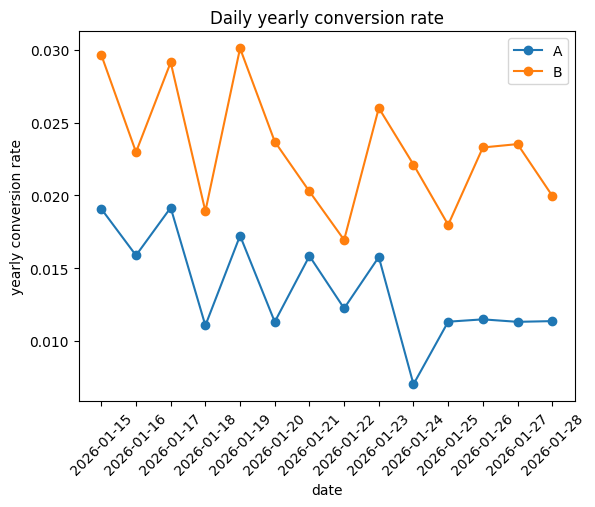

In [547]:
# 일자별 연간 구독 전환율
for group in ['A', 'B']:
    temp = daily_merge[daily_merge['group'] == group]
    plt.plot(temp['date'], temp['yearly_conversion_rate'], marker='o', label=group)

plt.title('Daily yearly conversion rate')
plt.xlabel('date')
plt.ylabel('yearly conversion rate')
plt.xticks(rotation=45)
plt.legend()
plt.show()

B안은 특정 하루에만 효과가 튄 것이 아니라 실험 기간 전반에 걸쳐 연간 구독 전환율을 A안보다 높게 유지한 것으로 보인다.

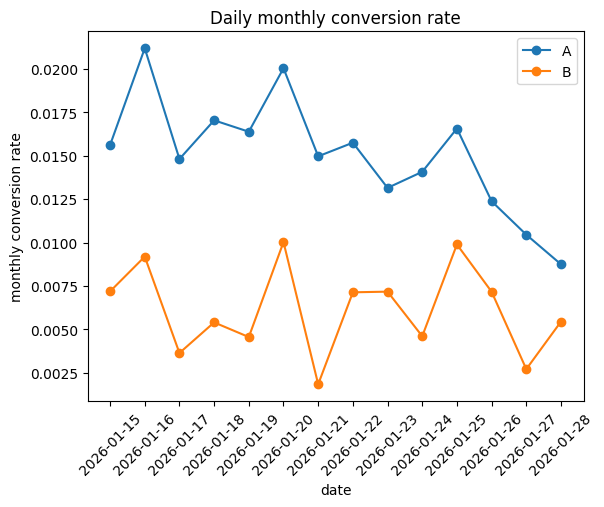

In [548]:
# 일자별 월간 구독 전환율
for group in ['A', 'B']:
    temp = daily_merge[daily_merge['group'] == group]
    plt.plot(temp['date'], temp['monthly_conversion_rate'], marker='o', label=group)

plt.title('Daily monthly conversion rate')
plt.xlabel('date')
plt.ylabel('monthly conversion rate')
plt.xticks(rotation=45)
plt.legend()
plt.show()

B안이 단순히 연간 구독도 늘리고 월간 구독도 늘린 게 아니라 월간 구독 선택을 줄이고 연간 구독 선택을 늘리는 방향으로 작동한 것을 알 수 있다.

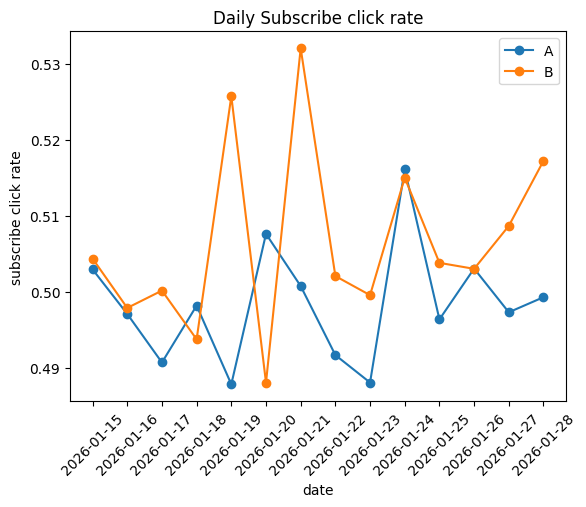

In [549]:
# 일자별 Subscribe 버튼 클릭률
for group in ['A', 'B']:
    temp = daily_merge[daily_merge['group'] == group]
    plt.plot(temp['date'], temp['subscribe_click_rate'], marker='o', label=group)

plt.title('Daily Subscribe click rate')
plt.xlabel('date')
plt.ylabel('subscribe click rate')
plt.xticks(rotation=45)
plt.legend()
plt.show()

Subscribe 버튼 클릭률은 전체적으로 B그룹이 소폭 높았지만, 일자별로는 변동이 있어 연간/월간 구독 전환율만큼 뚜렷한 차이는 아니었다.

#### 9-1-3. 일자별 지표 변화 분석 결과
B안은 일자별로 보아도 연간 멤버십 전환율을 높이는 방향으로 작동했으며 동시에 월간 멤버십 전환율은 낮추는 패턴을 보였다. 따라서 B안의 효과는 전체 구독 전환 증가보다는 구독 유형을 월간에서 연간으로 이동시키는 데 더 강하게 나타난 것으로 해석할 수 있다.

### 9-2. 신기효과 및 초두효과 확인

#### 9-2-1. 주차별 기준 피벗

In [550]:
# date를 날짜 타입으로 변환
daily_merge['date'] = pd.to_datetime(daily_merge['date'])

In [551]:
# 주차 구분
daily_merge['week'] = daily_merge['date'].apply(lambda x: 'Week 1' if x <= pd.to_datetime('2026-01-21') else 'Week 2')

In [552]:
# 주차별, 그룹별 핵심 지표 평균
weekly_summary = daily_merge.groupby(['week', 'group']).agg(
    subscribe_click_rate=('subscribe_click_rate', 'mean'),
    yearly_conversion_rate=('yearly_conversion_rate', 'mean'),
    monthly_conversion_rate=('monthly_conversion_rate', 'mean'),
    subscription_conversion_rate=('subscription_conversion_rate', 'mean')).reset_index()
weekly_summary

,week,group,subscribe_click_rate,yearly_conversion_rate,monthly_conversion_rate,subscription_conversion_rate
0,Week 1,A,0.497865,0.015659,0.017145,0.032805
1,Week 1,B,0.506001,0.024968,0.005980,0.030948
2,Week 2,A,0.498830,0.011512,0.013016,0.024528
3,Week 2,B,0.507059,0.021410,0.006306,0.027717


In [553]:
# 주차별 그룹 비교를 위한 피벗 생성
weekly_chart = weekly_summary.pivot_table(
    index='week',
    columns='group',
    values=[
        'subscribe_click_rate',
        'yearly_conversion_rate',
        'subscription_conversion_rate'])
weekly_chart

subscribe_click_rate           subscription_conversion_rate            \
group                     A         B                            A         B   
week                                                                           
Week 1             0.497865  0.506001                     0.032805  0.030948   
Week 2             0.498830  0.507059                     0.024528  0.027717   

       yearly_conversion_rate            
group                       A         B  
week                                     
Week 1               0.015659  0.024968  
Week 2               0.011512  0.021410

#### 9-2-2. 주차별 시각화

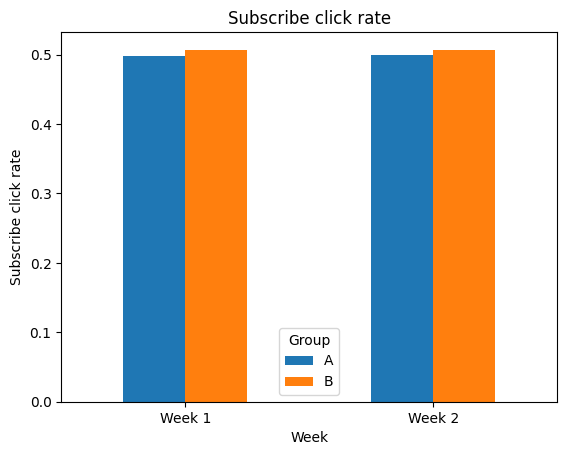

In [554]:
# 주차별 Subscribe 클릭률 시각화
weekly_chart['subscribe_click_rate'].plot(kind='bar')

plt.title('Subscribe click rate')
plt.xlabel('Week')
plt.ylabel('Subscribe click rate')
plt.xticks(rotation=0)
plt.legend(title='Group')
plt.show()

B-A 차이가 1주차와 2주차에서 거의 비슷하게 유지된다. 따라서 Subscribe 클릭률 기준으로는 B안의 효과가 초반에만 강했다가 빠르게 사라졌다고 보기는 어렵다.

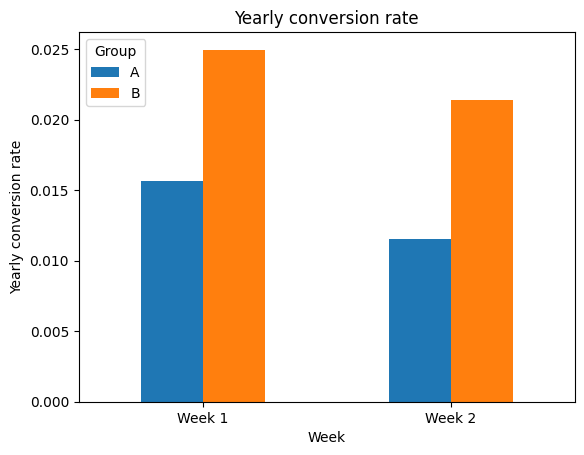

In [555]:
# 주차별 연간 구독 전환율 시각화
weekly_chart['yearly_conversion_rate'].plot(kind='bar')

plt.title('Yearly conversion rate')
plt.xlabel('Week')
plt.ylabel('Yearly conversion rate')
plt.xticks(rotation=0)
plt.legend(title='Group')
plt.show()

B안의 연간 구독 유도 효과는 2주차에도 유지되었지만 실험 초반보다 효과 크기는 다소 약해졌다.

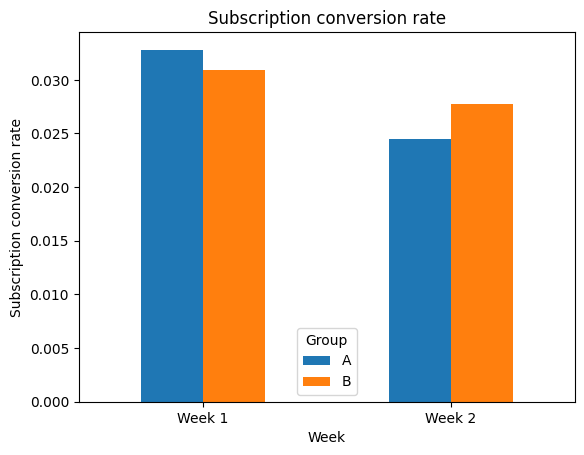

In [556]:
# 주차별 전체 구독 전환율 시각화
weekly_chart['subscription_conversion_rate'].plot(kind='bar')

plt.title('Subscription conversion rate')
plt.xlabel('Week')
plt.ylabel('Subscription conversion rate')
plt.xticks(rotation=0)
plt.legend(title='Group')
plt.show()

전체 구독 전환율은 Week 1에서는 A가 더 높고 Week 2에서는 B가 더 높다.하지만 차이가 아주 크지는 않다. 이건 앞서 검정 결과에서 전체 구독 전환율 차이가 통계적으로 유의하지 않았다는 결과와도 잘 맞다고 본다. 따라서 전체 구독 전환율 기준으로는 B안이 일관되게 우세하다고 보기 어렵다.

#### 9-2-3. 신기효과 및 초두효과 확인 결과
B안은 1주차와 2주차 모두에서 연간 멤버십 선택을 유도하는 효과를 보였지만, 2주차에는 전환율 수준이 다소 낮아졌다. 다만 A그룹에서도 유사하게 일부 지표 하락이 나타났기 때문에 이를 B안만의 신기효과로 단정하기는 어렵다. 실험 기간이 2주로 짧고, 요일별 트래픽 차이, 유입 유저 특성, 외부 광고나 마케팅 영향 등을 완전히 분리하기 어렵다. 따라서 본 결과는 신기효과의 확정적 근거가 아니라, 추가 관찰이 필요한 보조적 분석 결과로 해석하는 것이 적절하다.

### 9-3. 성별 세그먼트 분석

#### 9-3-1. 성별 기준 피벗

In [557]:
# 성별, 그룹별 핵심 지표 산출
df['gender_en'] = df['gender'].replace({'남성': 'Male','여성': 'Female'})
gender_summary = df.groupby(['gender_en', 'group']).apply(
    lambda x: pd.Series({
        'users': x['user_id'].count(),
        'subscribed_users': x['subscription_type'].notna().sum(),
        'ARPU': x['amount'].mean(),
        'yearly_conversion_rate': (x['subscription_type'] == 'yearly').mean(),
        'subscription_conversion_rate': x['subscription_type'].notna().mean(),
        'refund_inquiry_rate': (x.loc[x['subscription_type'].notna(), 'refund_inquiry'] > 0).mean()})).reset_index()
gender_summary

/tmp/ipykernel_53400/3635825992.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  gender_summary = df.groupby(['gender_en', 'group']).apply(


,gender_en,group,users,subscribed_users,ARPU,yearly_conversion_rate,subscription_conversion_rate,refund_inquiry_rate
0,Female,A,1231.0,440.0,59.639318,0.181966,0.357433,0.031818
1,Female,B,1225.0,476.0,90.982857,0.298776,0.388571,0.033613
2,Male,A,1321.0,480.0,54.283119,0.160484,0.363361,0.008333
3,Male,B,1217.0,429.0,86.611339,0.286771,0.352506,0.055944


In [558]:
# 성별 기준 그룹 비교를 위한 피벗 생성
gender_pivot = gender_summary.pivot_table(
    index='gender_en',
    columns='group',
    values=['ARPU', 'yearly_conversion_rate', 'refund_inquiry_rate'])
gender_pivot

ARPU            refund_inquiry_rate            \
group              A          B                   A         B   
gender_en                                                       
Female     59.639318  90.982857            0.031818  0.033613   
Male       54.283119  86.611339            0.008333  0.055944   

          yearly_conversion_rate            
group                          A         B  
gender_en                                   
Female                  0.181966  0.298776  
Male                    0.160484  0.286771

#### 9-3-2. 성별 세그먼트 분석 시각화

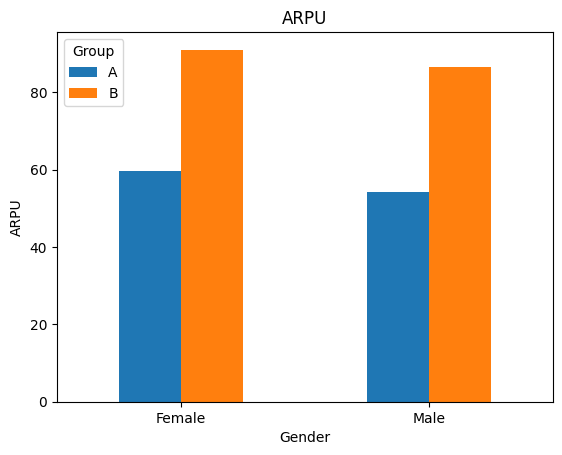

In [559]:
# 성별에 따른 그룹별 ARPU 시각화
gender_arpu = gender_summary.pivot_table(
    index='gender_en',
    columns='group',
    values='ARPU')

gender_arpu.plot(kind='bar')

plt.title('ARPU')
plt.xlabel('Gender')
plt.ylabel('ARPU')
plt.xticks(rotation=0)
plt.legend(title='Group')
plt.show()

성별과 관계없이 B그룹의 ARPU가 A그룹보다 높게 나타났다. B안의 매출 개선 효과가 특정 성별에만 한정된 결과라기보다는 성별 전반에서 공통적으로 나타난 효과로 볼 수 있다.

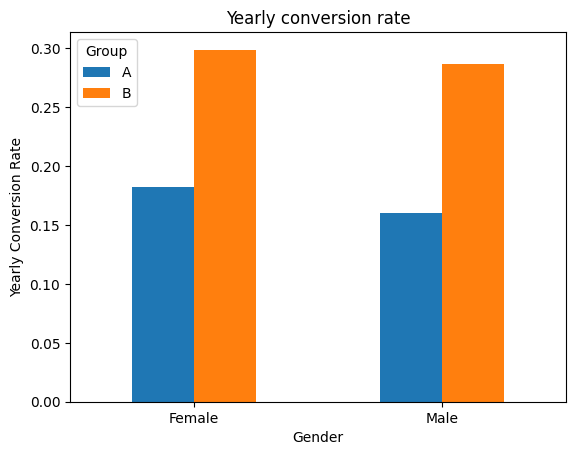

In [560]:
# 성별에 따른 그룹별 연간 구독 전환율 시각화
gender_yearly = gender_summary.pivot_table(
    index='gender_en',
    columns='group',
    values='yearly_conversion_rate')

gender_yearly.plot(kind='bar')

plt.title('Yearly conversion rate')
plt.xlabel('Gender')
plt.ylabel('Yearly Conversion Rate')
plt.xticks(rotation=0)
plt.legend(title='Group')
plt.show()

연간 구독 전환율도 여성과 남성 모두에서 B그룹이 A그룹보다 높게 나타났다. B안의 핵심 효과였던 연간 멤버십 선택 유도 효과는 성별과 관계없이 나타났다고 볼 수 있다.

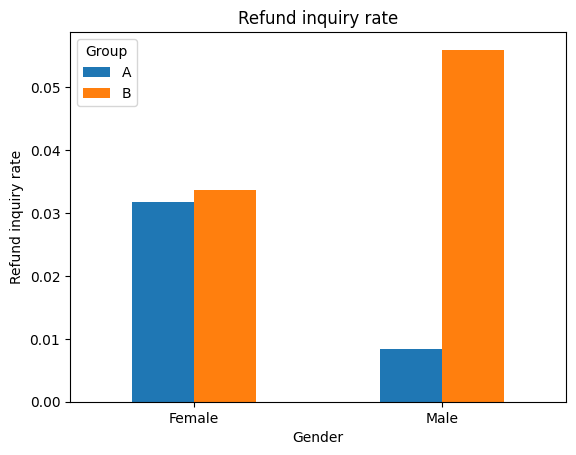

In [561]:
# 성별에 따른 그룹별 환불 문의율 시각화
gender_refund = gender_summary.pivot_table(
    index='gender_en',
    columns='group',
    values='refund_inquiry_rate')

gender_refund.plot(kind='bar')

plt.title('Refund inquiry rate')
plt.xlabel('Gender')
plt.ylabel('Refund inquiry rate')
plt.xticks(rotation=0)
plt.legend(title='Group')
plt.show()

여성 세그먼트에서는 A/B 간 환불 문의율 차이가 거의 크지 않다. 반면 남성 세그먼트에서는 B그룹의 환불 문의율이 A그룹보다 크게 높게 나타났다. 위 검정에서 B그룹의 환불 문의율이 유의하게 높았는데 성별로 나누어 보면 그 리스크가 남성 세그먼트에서 더 두드러졌을 가능성이 보인다.

#### 9-3-3. 성별 세그먼트 분석 결과
B안은 여성과 남성 모두에서 ARPU와 연간 구독 전환율을 높이는 방향으로 작동했다. 그러나 환불 문의율 측면에서는 남성 세그먼트에서 리스크가 더 크게 나타날 가능성이 있으므로 최종 도입 시 가격 안내 문구를 더 명확하게 보완할 필요가 있다.

### 9-4. 연령대 세그먼트 분석

#### 9-4-1. 연령대 기준 피벗

In [562]:
# 연령대 생성
df['age_group'] = pd.cut(
    df['age'],
    bins=[0, 19, 29, 39, 49, 59, 100],
    labels=['10s', '20s', '30s', '40s', '50s', '60s +'])

In [563]:
# 연령대별, 그룹별 핵심 지표 산출
age_summary = df.groupby(['age_group', 'group'], observed=True).apply(
    lambda x: pd.Series({
        'users': x['user_id'].count(),
        'subscribed_users': x['subscription_type'].notna().sum(),
        'ARPU': x['amount'].mean(),
        'yearly_conversion_rate': (x['subscription_type'] == 'yearly').mean(),
        'subscription_conversion_rate': x['subscription_type'].notna().mean(),
        'refund_inquiry_rate': (x.loc[x['subscription_type'].notna(), 'refund_inquiry'] > 0).mean()})).reset_index()
age_summary

/tmp/ipykernel_53400/3165807995.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  age_summary = df.groupby(['age_group', 'group'], observed=True).apply(


,age_group,group,users,subscribed_users,ARPU,yearly_conversion_rate,subscription_conversion_rate,refund_inquiry_rate
0,20s,A,750.0,262.0,52.976000,0.157333,0.349333,0.022901
1,20s,B,751.0,300.0,98.130493,0.324900,0.399467,0.046667
2,30s,A,988.0,354.0,60.251012,0.184211,0.358300,0.028249
3,30s,B,1011.0,335.0,75.386746,0.246291,0.331355,0.035821
4,40s,A,658.0,256.0,60.063830,0.179331,0.389058,0.000000
5,40s,B,540.0,222.0,100.722222,0.333333,0.411111,0.054054
6,50s,A,144.0,46.0,39.958333,0.111111,0.319444,0.043478
7,50s,B,134.0,44.0,88.805970,0.298507,0.328358,0.045455
8,60s +,A,12.0,2.0,49.000000,0.166667,0.166667,0.000000
9,60s +,B,6.0,4.0,109.666667,0.333333,0.666667,0.000000


In [564]:
age_pivot = age_summary.pivot_table(
    index='age_group',
    columns='group',
    values=['ARPU', 'yearly_conversion_rate', 'refund_inquiry_rate'],
    observed=True)

#### 9-4-2. 연령대 세그먼트 분석 시각화

/tmp/ipykernel_53400/696019114.py:2: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  age_arpu = age_summary.pivot_table(


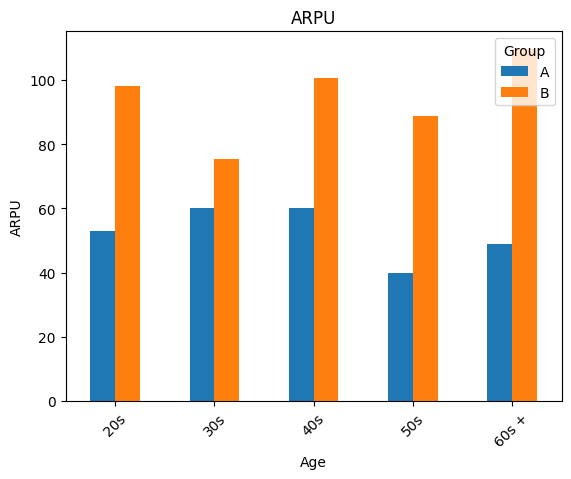

In [565]:
# 연령대에 따른 그룹별 ARPU 시각화
age_arpu = age_summary.pivot_table(
    index='age_group',
    columns='group',
    values='ARPU')

age_arpu.plot(kind='bar')

plt.title('ARPU')
plt.xlabel('Age')
plt.ylabel('ARPU')
plt.xticks(rotation=45)
plt.legend(title='Group')
plt.show()

대부분의 연령대에서 B그룹이 A그룹보다 높게 나타났다.

/tmp/ipykernel_53400/1640906632.py:2: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  age_arpu = age_summary.pivot_table(


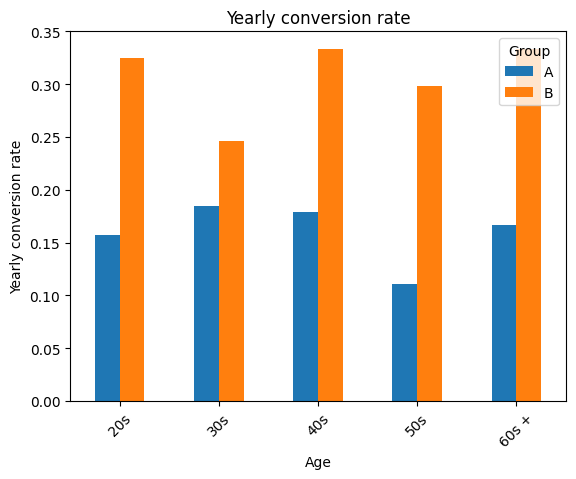

In [566]:
# 연령대에 따른 그룹별 연간 구독 전환율 시각화
age_arpu = age_summary.pivot_table(
    index='age_group',
    columns='group',
    values='yearly_conversion_rate')

age_arpu.plot(kind='bar')

plt.title('Yearly conversion rate')
plt.xlabel('Age')
plt.ylabel('Yearly conversion rate')
plt.xticks(rotation=45)
plt.legend(title='Group')
plt.show()

연간 구독 전환율 역시 주요 연령대에서 B그룹이 A그룹보다 높게 나타났다.

/tmp/ipykernel_53400/376561062.py:2: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  age_refund = age_summary.pivot_table(


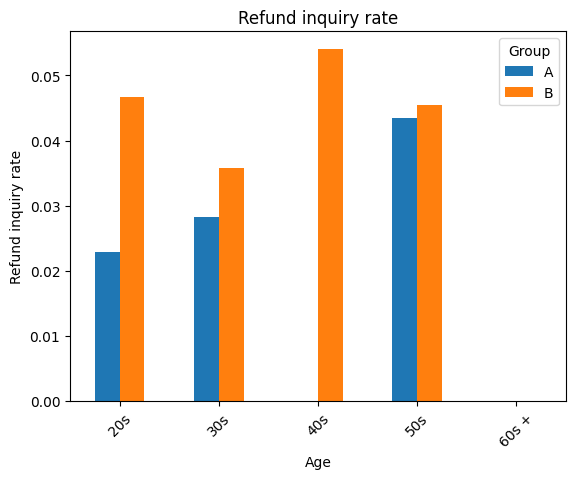

In [567]:
# 연령대에 따른 그룹별 환불 문의율 시각화
age_refund = age_summary.pivot_table(
    index='age_group',
    columns='group',
    values='refund_inquiry_rate')

age_refund.plot(kind='bar')

plt.title('Refund inquiry rate')
plt.xlabel('Age')
plt.ylabel('Refund inquiry rate')
plt.xticks(rotation=45)
plt.legend(title='Group')
plt.show()

환불 문의율은 일부 연령대에서 B그룹이 A그룹보다 높게 나타났다.

#### 9-4-3. 연령대 세그먼트 분석 결과
50대 이상, 특히 60대 이상은 표본 수가 적기 때문에 위 결과를 일반화하기는 어렵다. 따라서 연령대별 분석은 최종 결론을 단정하기 위한 근거라기보다 B안 도입 시 추가로 주의해야 할 세그먼트를 확인하는 보조 분석으로 해석하는 것이 적절하다.

### 9-5. 기기별 세그먼트 분석

#### 9-5-1. 기기 기준 피벗

In [718]:
# 기기별 분석용 데이터 생성
daily_device = daily_df[['user_id', 'device']].drop_duplicates()

device_df = daily_device.merge(
    df[['user_id', 'group', 'amount', 'subscription_type', 'refund_inquiry']],
    on='user_id',
    how='left')
device_df.head()

,user_id,device,group,amount,subscription_type,refund_inquiry
0,U2501,PC,B,294.0,yearly,0.0
1,U2501,Mobile,B,294.0,yearly,0.0
2,U2502,Mobile,A,0.0,NaN,0.0
3,U2502,PC,A,0.0,NaN,0.0
4,U2503,Mobile,B,294.0,yearly,0.0


In [719]:
# 기기/그룹별 핵심 지표 산출
device_summary = device_df.groupby(['device', 'group']).apply(
    lambda x: pd.Series({
        'users': x['user_id'].nunique(),
        'subscribed_users': x.loc[x['subscription_type'].notna(), 'user_id'].nunique(),
        'ARPU': x.drop_duplicates('user_id')['amount'].mean(),
        'yearly_conversion_rate': (
            x.drop_duplicates('user_id')['subscription_type'] == 'yearly'
        ).mean(),
        'subscription_conversion_rate': (
            x.drop_duplicates('user_id')['subscription_type'].notna()
        ).mean(),
        'refund_inquiry_rate': (
            x.loc[x['subscription_type'].notna()]
             .drop_duplicates('user_id')['refund_inquiry'] > 0).mean()})).reset_index()
device_summary

/tmp/ipykernel_53400/3868138910.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  device_summary = device_df.groupby(['device', 'group']).apply(


,device,group,users,subscribed_users,ARPU,yearly_conversion_rate,subscription_conversion_rate,refund_inquiry_rate
0,Mobile,A,1277.0,460.0,56.822240,0.170713,0.360219,0.019565
1,Mobile,B,1223.0,453.0,88.779231,0.292723,0.370401,0.044150
2,PC,A,1275.0,460.0,56.911373,0.170980,0.360784,0.019565
3,PC,B,1219.0,452.0,88.829368,0.292863,0.370796,0.044248


In [720]:
# 기기 기준 그룹 비교를 위한 피벗 생성
device_pivot = device_summary.pivot_table(
    index='device',
    columns='group',
    values=['ARPU', 'yearly_conversion_rate', 'refund_inquiry_rate'])
device_pivot

ARPU            refund_inquiry_rate            \
group           A          B                   A         B   
device                                                       
Mobile  56.822240  88.779231            0.019565  0.044150   
PC      56.911373  88.829368            0.019565  0.044248   

       yearly_conversion_rate            
group                       A         B  
device                                   
Mobile               0.170713  0.292723  
PC                   0.170980  0.292863

#### 9-5-2. 기기별 세그먼트 분석 시각화

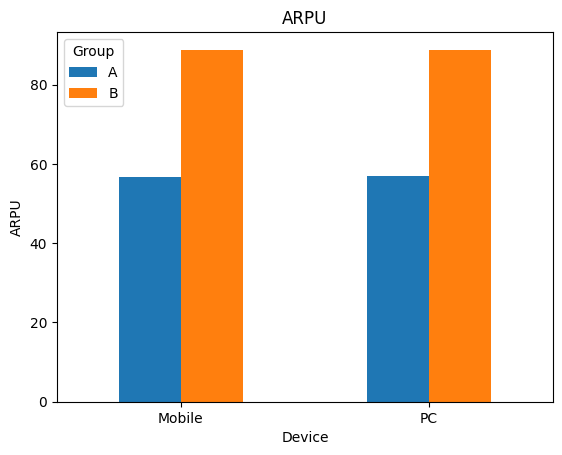

In [721]:
# 기기에 따른 그룹별 ARPU 시각화
device_arpu = device_summary.pivot_table(
    index='device',
    columns='group',
    values='ARPU')

device_arpu.plot(kind='bar')

plt.title('ARPU')
plt.xlabel('Device')
plt.ylabel('ARPU')
plt.xticks(rotation=0)
plt.legend(title='Group')
plt.show()

B안의 매출 개선 효과는 특정 기기에서만 나타난 것이 아니라 Mobile과 PC 모두에서 비슷하게 나타났다.

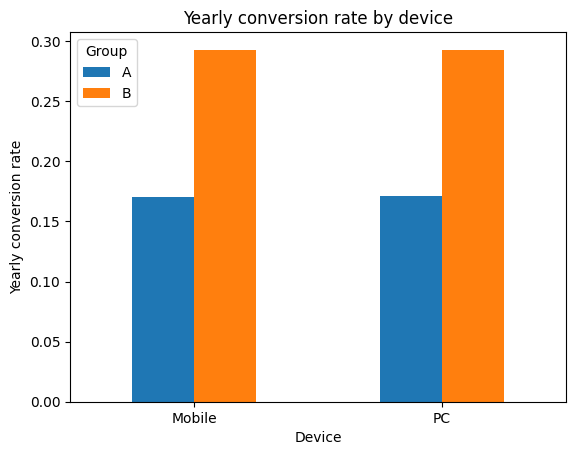

In [722]:
# 기기에 따른 그룹별 연간 구독 전환율 시각화
device_yearly = device_summary.pivot_table(
    index='device',
    columns='group',
    values='yearly_conversion_rate')

device_yearly.plot(kind='bar')

plt.title('Yearly conversion rate by device')
plt.xlabel('Device')
plt.ylabel('Yearly conversion rate')
plt.xticks(rotation=0)
plt.legend(title='Group')
plt.show()

B안의 연간 멤버십 유도 효과는 Mobile과 PC 양쪽에서 모두 확인되지만 기기별 차이는 거의 없는 편이다.

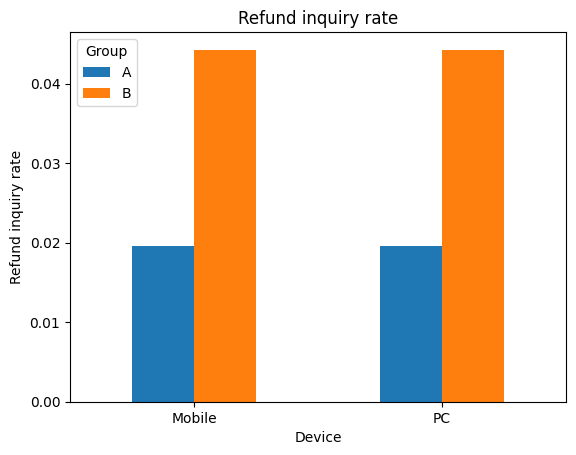

In [723]:
# 기기에 따른 그룹별 환불 문의율 시각화
device_refund = device_summary.pivot_table(
    index='device',
    columns='group',
    values='refund_inquiry_rate')

device_refund.plot(kind='bar')

plt.title('Refund inquiry rate')
plt.xlabel('Device')
plt.ylabel('Refund inquiry rate')
plt.xticks(rotation=0)
plt.legend(title='Group')
plt.show()

B안에서 환불 문의율이 높아지는 리스크는 특정 기기에서만 발생했다기보다는 기기와 관계없이 전반적으로 나타난 리스크로 보인다.

#### 9-5-3. 기기별 세그먼트 분석 결과
Mobile과 PC의 지표 차이가 거의 크지 않기 때문에 기기별로 B안의 효과가 뚜렷하게 다르다고 보기는 어렵다. 따라서 기기별 분석은 특정 기기에서만 다른 패턴이 나타났는지 확인하기 위한 보조 분석으로 해석하는 것이 적절하다.

### 9-6. 추가 분석 결과 요약
추가 분석 결과는 앞선 가설검정 결과를 보조적으로 뒷받침한다. B안은 날짜, 성별, 연령대, 기기 기준으로 보아도 전반적으로 연간 멤버십 선택을 유도하고 ARPU를 높이는 방향으로 작동했다. 다만 환불 문의율 증가 리스크도 함께 확인되었기 때문에, B안을 그대로 전면 도입하기보다는 실제 연간 결제 금액, 결제 주기, 환불 불가 조건 등을 더 명확하게 안내하는 방식으로 보완할 필요가 있다.

## 10\. 결론 및 제안

### 10-1. A/B 테스트 결과 요약
A/B 테스트 결과, B안은 매출 지표 측면에서 기존 A안보다 긍정적인 결과를 보였다. 성공 지표인 ARPU는 A그룹 56.82, B그룹 88.78로 B그룹이 더 높게 나타났으며, Welch t-검정 결과 통계적으로 유의한 차이가 확인되었다. 보조 지표인 ARPPU 역시 A그룹 157.74, B그룹 239.68로 B그룹이 유의하게 높게 나타났다.

다만 전체 구독 전환율은 A그룹 36.02%, B그룹 37.04%로 B그룹이 소폭 높았지만, 모비율 Z검정 결과 통계적으로 유의한 차이는 확인되지 않았다. 따라서 B안이 전체 구독자 수 자체를 유의하게 늘렸다고 보기는 어렵다.

반면 구독 유형을 나누어 보면 B안의 효과가 뚜렷하게 나타났다. 연간 멤버십 구독 전환율은 A그룹 17.07%, B그룹 29.27%로 B그룹이 유의하게 높았고, 월간 멤버십 구독 전환율은 A그룹 18.95%, B그룹 7.77%로 B그룹이 유의하게 낮았다. 이는 B안이 전체 구독 전환율을 크게 높였다기보다는, 유저의 선택을 월간 멤버십에서 연간 멤버십으로 이동시키는 방향으로 작동했음을 보여준다.

클릭 지표에서도 유사한 흐름이 확인되었다. Subscribe 버튼 클릭률은 B그룹이 A그룹보다 유의하게 높았으며, 연간 멤버십 버튼 클릭률도 B그룹에서 유의하게 높게 나타났다. 반면 월간 멤버십 버튼 클릭률은 B그룹에서 유의하게 낮았다. 이는 B안의 연간 멤버십 1개월 가격 강조 방식이 클릭 단계에서부터 연간 멤버십에 대한 관심을 높였을 가능성을 보여준다.

가드레일 지표에서는 구독 취소율과 환불 문의율의 결과가 다르게 나타났다. 구독 취소율은 B그룹이 A그룹보다 소폭 높았지만 통계적으로 유의한 차이는 아니었다. 반면 환불 문의율은 A그룹 1.96%, B그룹 4.42%로 B그룹이 유의하게 높게 나타났다. 이는 B안의 가격 표현 방식이 일부 유저에게 실제 결제 금액에 대한 혼동이나 불만을 유발했을 가능성을 시사한다.

### 10-2. 최종 의사결정
최종적으로 B안은 바로 전면 도입하기보다는, 가격 안내 문구를 보완한 뒤 조건부 도입 또는 후속 실험을 진행하는 것이 적절하다고 판단한다.

B안은 성공 지표인 ARPU를 유의하게 높였고, ARPPU와 연간 멤버십 구독 전환율도 유의하게 증가시켰다. 또한 일자별, 성별, 연령대, 기기별 추가 분석에서도 B안이 전반적으로 연간 멤버십 선택을 유도하는 방향으로 작동한 것을 확인할 수 있었다. 따라서 매출 극대화라는 실험 목표 측면에서는 B안이 기존 A안보다 더 효과적이었다고 볼 수 있다.

그러나 전체 구독 전환율 자체는 유의하게 증가하지 않았고, 환불 문의율이 B그룹에서 유의하게 높게 나타났다는 점은 중요한 리스크이다. 즉, B안은 더 많은 유저를 구독자로 전환시켰다기보다는 기존에 구독 의향이 있던 유저의 선택을 연간 멤버십으로 이동시켜 매출을 높인 것으로 해석된다.

따라서 B안의 구조는 유지하되, 실제 연간 결제 금액과 결제 주기, 중도 환불 불가 조건을 더 명확하게 안내하는 방식으로 보완한 뒤 적용하는 것이 적절하다.

### 10-3. 의사결정 시 유의사항
이번 실험 결과를 해석할 때 가장 유의해야 할 점은 ARPU 상승의 원인이다. B안은 전체 구독 전환율을 유의하게 높이지는 못했지만, 연간 멤버십 구독 전환율과 ARPPU를 유의하게 높였다. 따라서 B안의 매출 개선 효과는 전체 구독자 수 증가보다는 연간 멤버십 선택 증가에서 비롯된 것으로 보는 것이 적절하다.

또한 환불 문의율이 B그룹에서 유의하게 증가했다는 점을 함께 고려해야 한다. 연간 멤버십의 1개월 가격을 강조하는 방식은 유저에게 가격을 더 매력적으로 보이게 만들 수 있지만, 실제 결제 금액이 연간 단위로 청구된다는 점이 충분히 명확하지 않으면 오해나 불만을 유발할 수 있다.

추가 분석에서도 B안의 매출 개선 효과는 성별, 연령대, 기기 기준으로 전반적으로 확인되었지만, 일부 세그먼트에서는 환불 문의율이 더 높게 나타날 가능성이 있었다. 따라서 최종 도입 시에는 단기 매출 증가뿐 아니라 유저 신뢰도, 가격 안내의 명확성, 고객센터 문의 증가 가능성을 함께 고려해야 한다.

또한 신기효과 및 초두효과 분석에서는 B안의 연간 구독 유도 효과가 1주차와 2주차 모두에서 확인되었지만, 일부 지표는 A/B 그룹 모두에서 함께 하락하는 모습을 보였다. 따라서 이를 B안만의 신기효과로 단정하기는 어렵고, 요일별 트래픽 차이, 유입 유저 특성, 외부 광고나 마케팅 영향도 함께 고려해야 한다.

### 10-4. 후속 A/B 테스트 제안
후속 A/B 테스트에서는 B안의 장점인 연간 멤버십 선택 유도 효과는 유지하되, 환불 문의율 증가 리스크를 줄이는 방향으로 개선안을 설계하는 것이 필요하다.

후속 실험안으로는 기존 B안처럼 연간 멤버십의 월 환산 가격을 강조하되, 결제 버튼 주변에 실제 연간 결제 금액, 결제 주기, 중도 환불 불가 조건을 더 명확하게 함께 노출하는 C안을 제안한다. 예를 들어 “월 환산 가격”을 강조하더라도, 바로 아래에 “연간 결제 금액”, “1년 단위 결제”, “중도 환불 불가”와 같은 정보를 함께 보여주는 방식이다.

후속 실험의 성공 지표는 기존과 동일하게 ARPU로 설정하되, 가드레일 지표로 환불 문의율을 더 중요하게 관리하는 것이 적절하다. C안이 B안 수준의 ARPU와 연간 구독 전환율을 유지하면서 환불 문의율을 낮춘다면, 전면 도입 가능성이 더 높아질 것이다.

따라서 다음 실험의 목표는 단순히 매출을 더 높이는 것이 아니라, 매출 개선 효과와 가격 안내의 명확성을 동시에 확보하는 것으로 설정하는 것이 적절하다.